In [1]:
import pandas as pd
import numpy as np
import pickle as pk
import os
import re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import Dataset
from glob import glob

/usr/local/mambaforge/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def natural_sort(l): 
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(l, key=alphanum_key)

# dataset
class SparseEvent(Dataset):
    def __init__(self, root, shuffle=False, **kwargs):
        '''Initialiser for SparseEventProtoDUNE class'''
        
        self.root = root
        self.data_files = self.processed_file_names
        if shuffle:
            random.shuffle(self.data_files) 
        self.total_events = self.__len__
    
    @property
    def processed_dir(self):
        return f'{self.root}'
    
    @property
    def processed_file_names(self):
        return natural_sort(glob(f'{self.processed_dir}*.npz'))
    
    def __len__(self):
        return len(self.data_files)
    
    def __getitem__(self, idx):
        data = np.load(self.data_files[idx])
        
        c = data['c_rel']
        x = data['x_rel']
        y = data['y_rel']
        relevant_slices = data['relevant_slices']
        
        # keep two labels
        y[y!=0]=1
        y[y<0]=0
        
        del data
        return { 'x': x, 'c': c, 'y': y}
    
    def combine_slices(self, idx):
        print(self.data_files[idx])
        
        data = np.load(self.data_files[idx])
        coords = data['c_rel']
        true = data['y_rel']
        
        # define grid
        fig, ax = plt.subplots(1, 1)
        fig.set_figheight(5)
        fig.set_figwidth(5)
        
        # merge trough Z-axis
        coords_aux = coords[np.lexsort((coords[:,1], coords[:,0]))]
        sorted_coords, indexes = np.unique(coords_aux[:,:2], axis=0, return_index=True)
        sums = np.array([sum(x) for x in np.split(true[:,0], indexes)[1:]])
        sums[sums>1]=1
        
        # define lims and subplot titles
        ax.set_xlim(0, 512)
        ax.set_ylim(512, 0)
        ax.title.set_text('Original')
        
        # plot
        ax.scatter(sorted_coords[:,0], sorted_coords[:,1], c=sums, marker='s')
        
        plt.show()

In [3]:
#ranges = [-300,500]
#ranges = [-50, 300]
ranges = [0,200]

# generate dataset
dataset=SparseEvent("data_{}_{}/event_kits21*".format(ranges[0], ranges[1]))

data_0_200/event_kits21_00000.npz


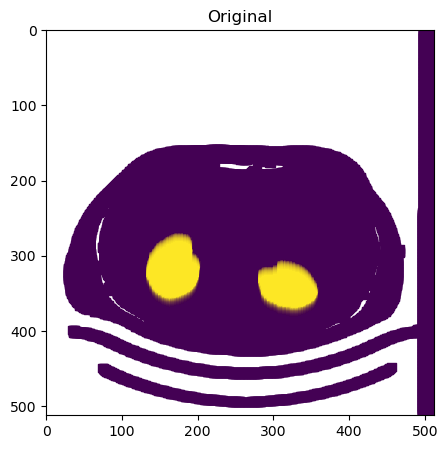

data_0_200/event_kits21_00001.npz


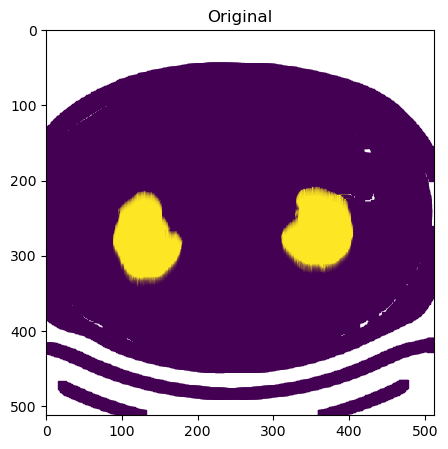

data_0_200/event_kits21_00002.npz


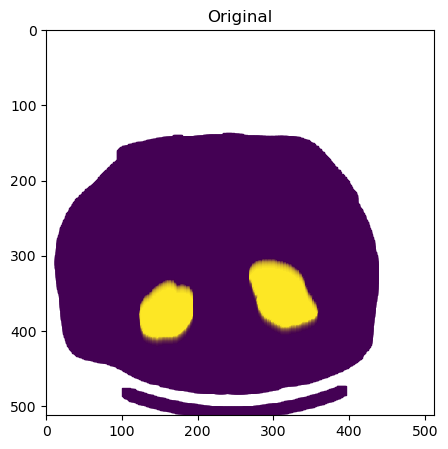

data_0_200/event_kits21_00003.npz


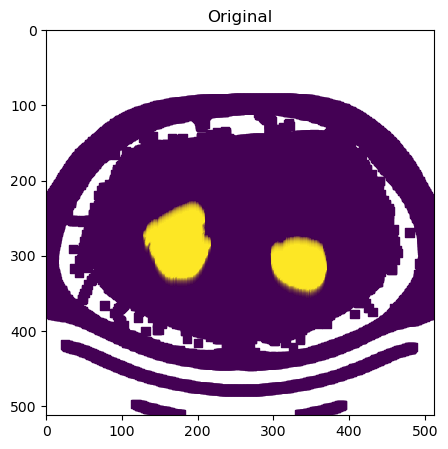

data_0_200/event_kits21_00004.npz


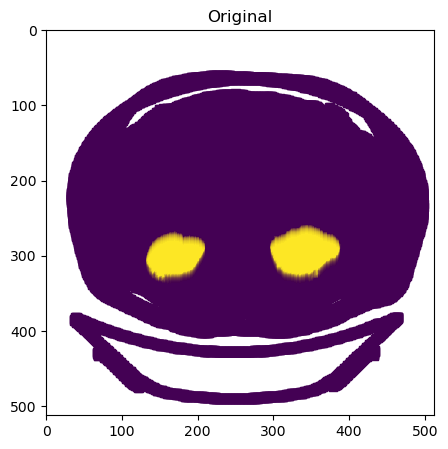

data_0_200/event_kits21_00005.npz


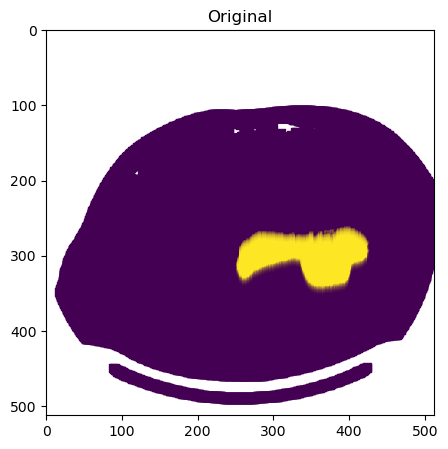

data_0_200/event_kits21_00006.npz


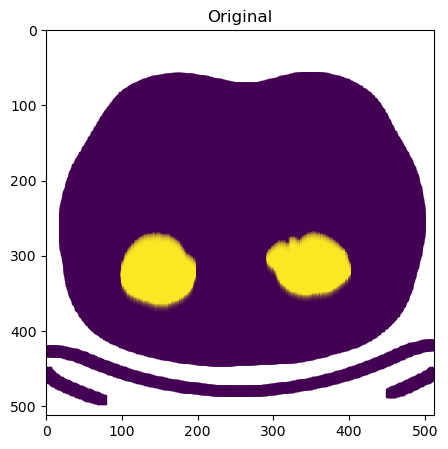

data_0_200/event_kits21_00007.npz


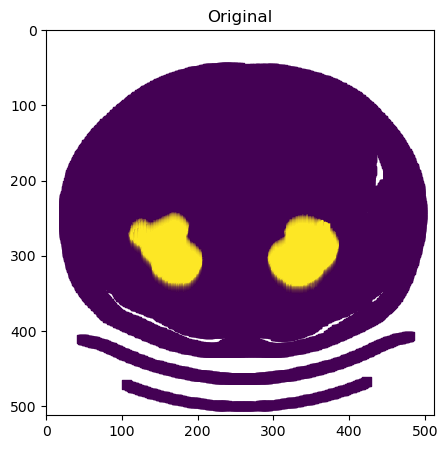

data_0_200/event_kits21_00008.npz


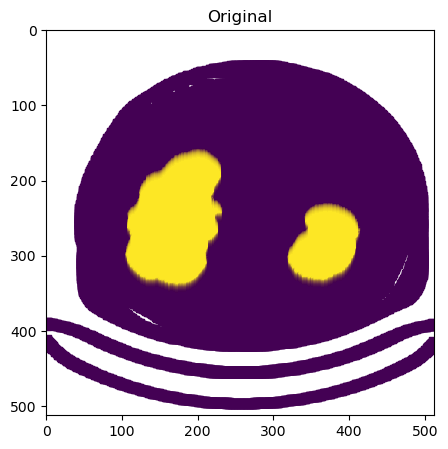

data_0_200/event_kits21_00009.npz


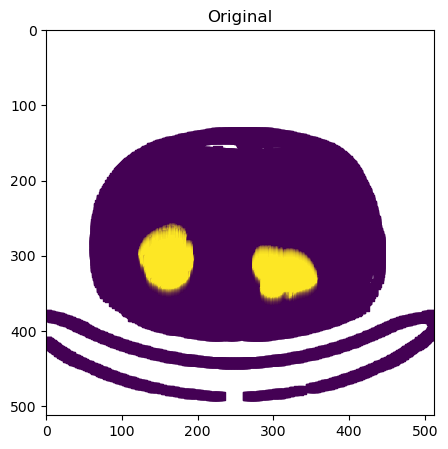

data_0_200/event_kits21_00010.npz


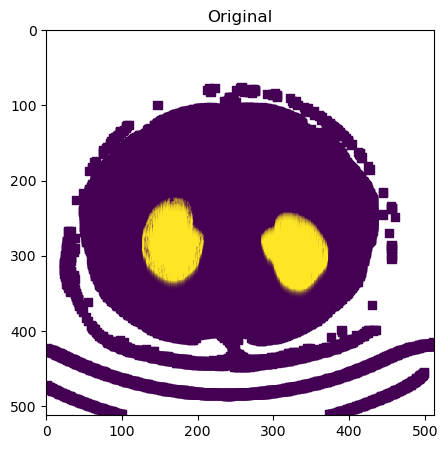

data_0_200/event_kits21_00011.npz


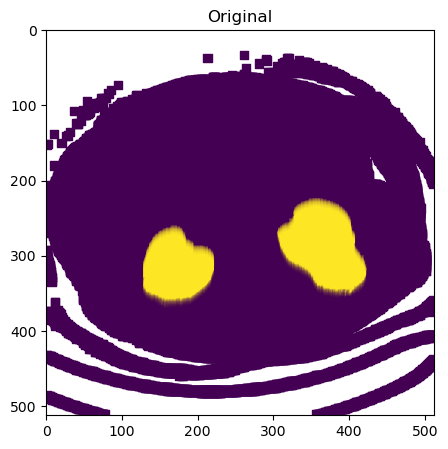

data_0_200/event_kits21_00012.npz


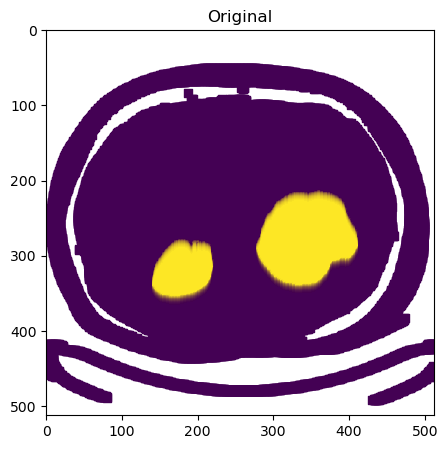

data_0_200/event_kits21_00013.npz


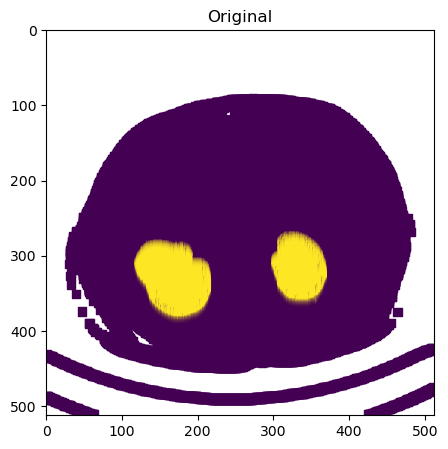

data_0_200/event_kits21_00014.npz


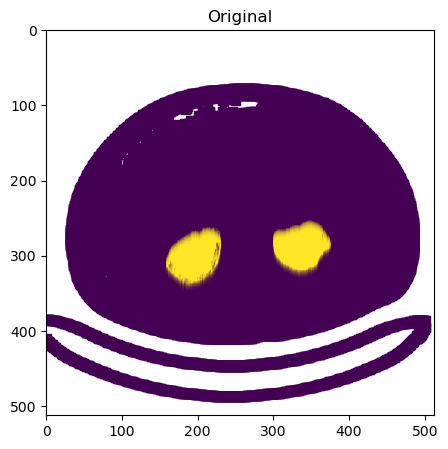

data_0_200/event_kits21_00016.npz


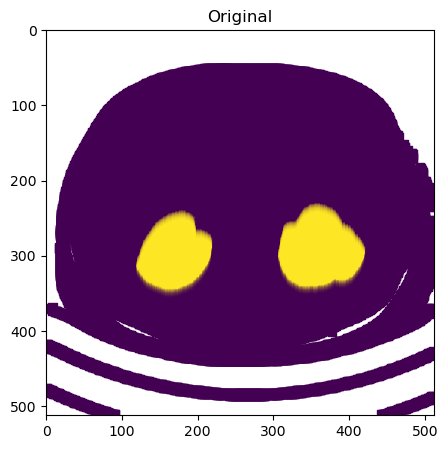

data_0_200/event_kits21_00017.npz


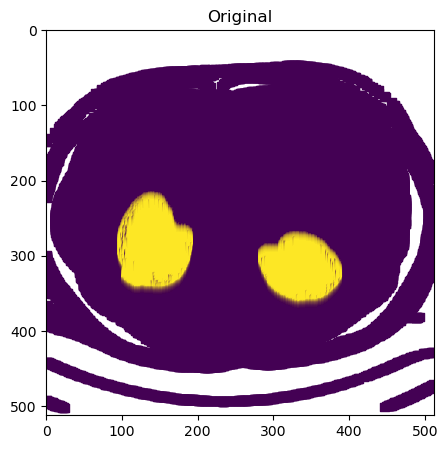

data_0_200/event_kits21_00018.npz


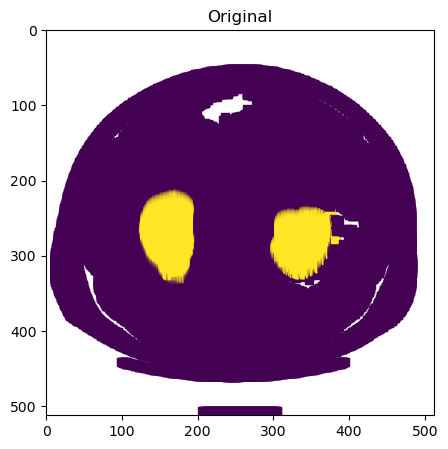

data_0_200/event_kits21_00019.npz


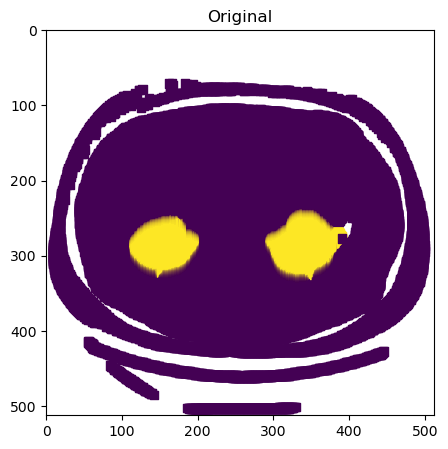

data_0_200/event_kits21_00020.npz


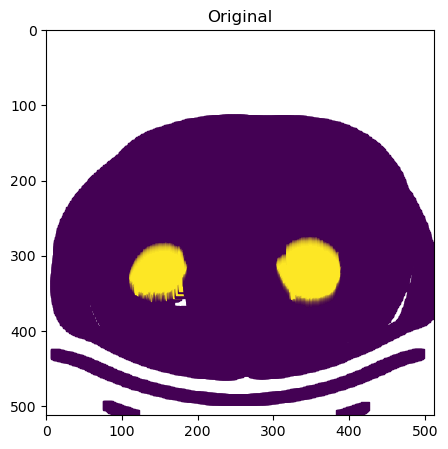

data_0_200/event_kits21_00021.npz


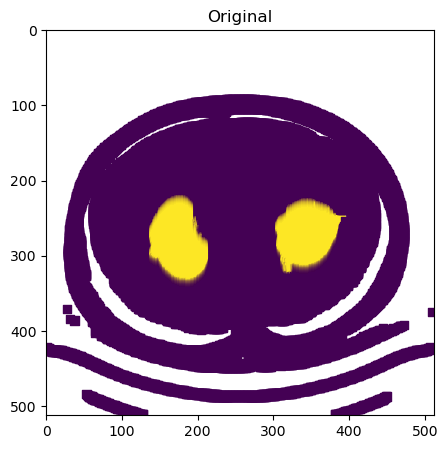

data_0_200/event_kits21_00022.npz


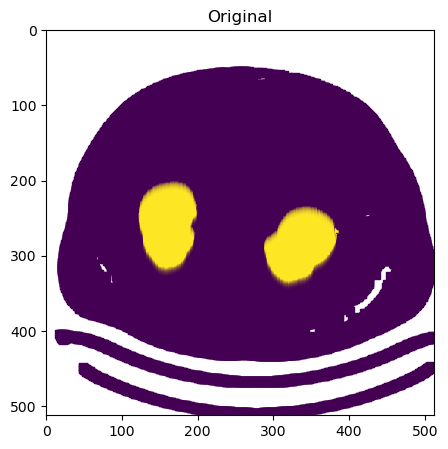

data_0_200/event_kits21_00023.npz


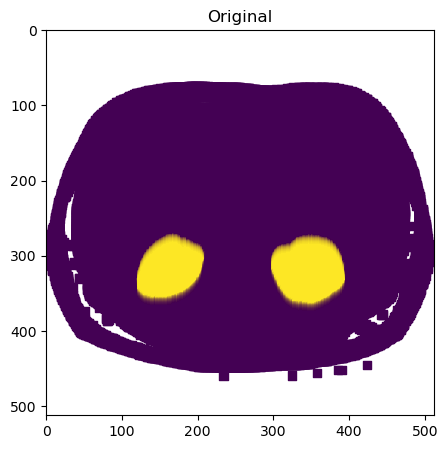

data_0_200/event_kits21_00024.npz


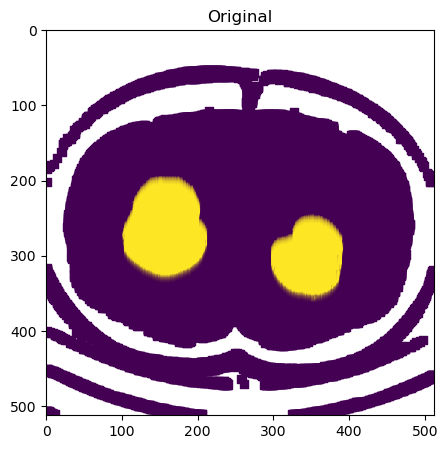

data_0_200/event_kits21_00025.npz


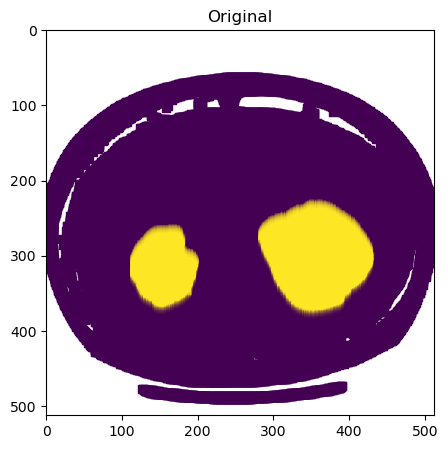

data_0_200/event_kits21_00026.npz


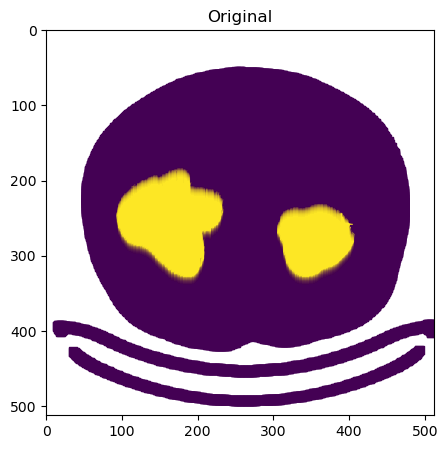

data_0_200/event_kits21_00027.npz


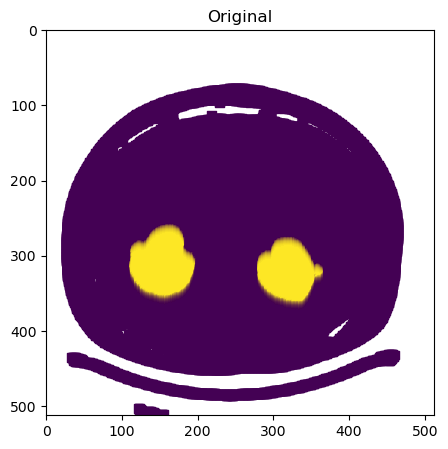

data_0_200/event_kits21_00028.npz


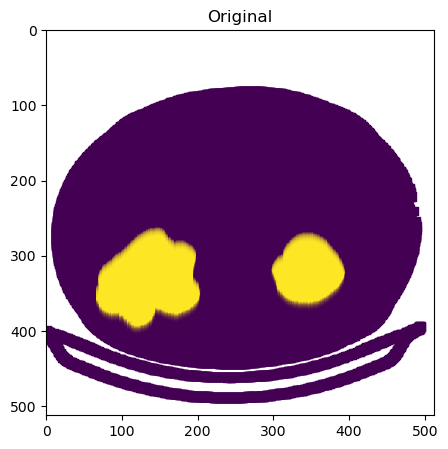

data_0_200/event_kits21_00029.npz


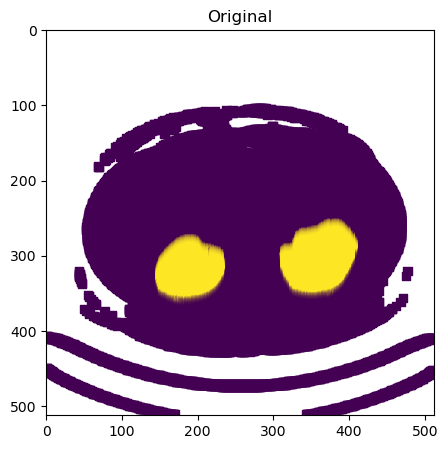

data_0_200/event_kits21_00030.npz


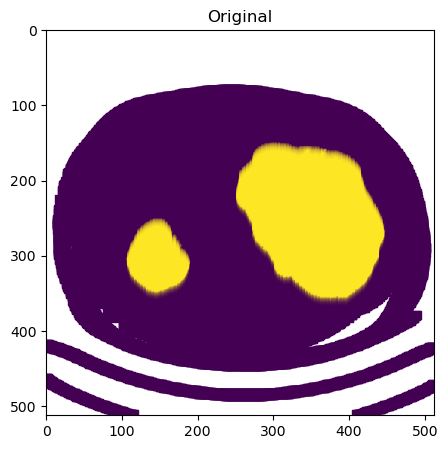

data_0_200/event_kits21_00031.npz


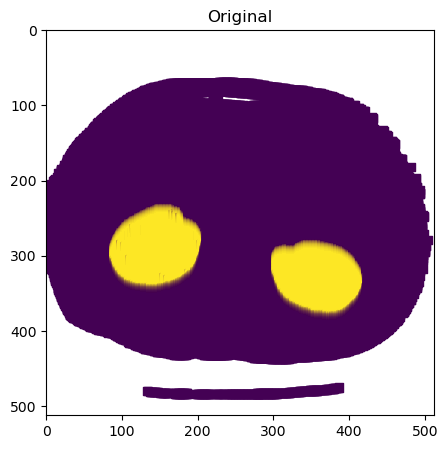

data_0_200/event_kits21_00032.npz


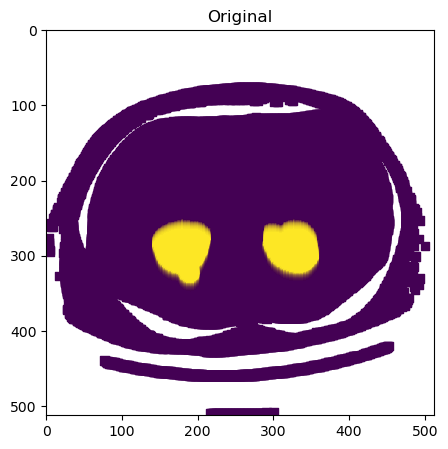

data_0_200/event_kits21_00033.npz


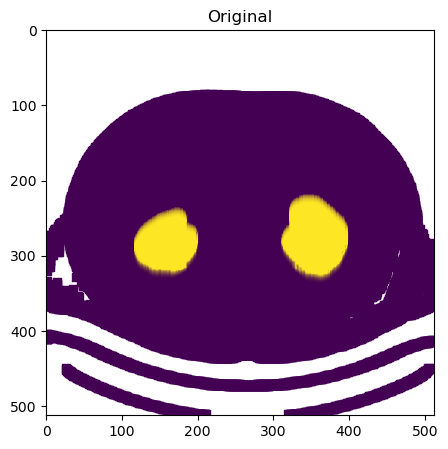

data_0_200/event_kits21_00034.npz


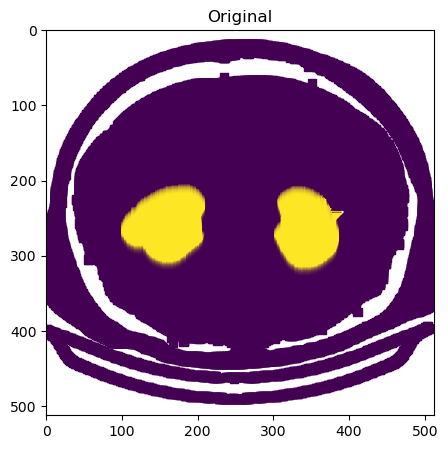

data_0_200/event_kits21_00035.npz


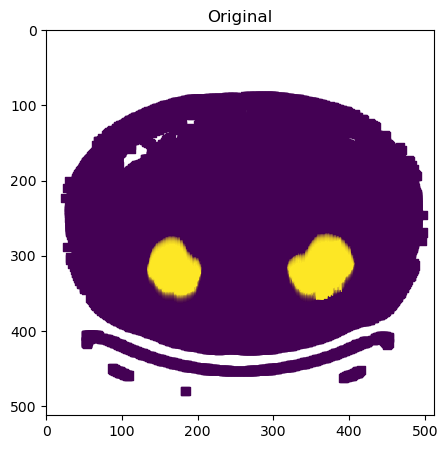

data_0_200/event_kits21_00036.npz


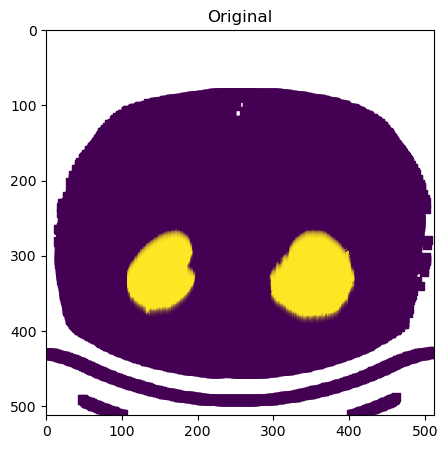

data_0_200/event_kits21_00037.npz


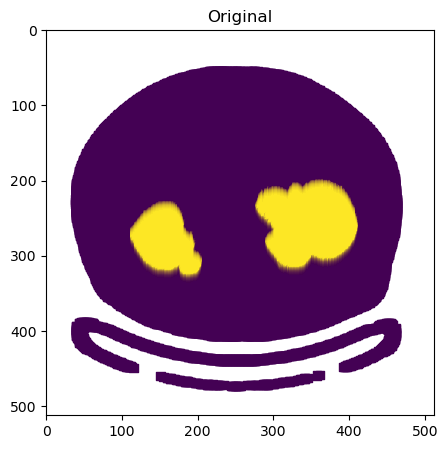

data_0_200/event_kits21_00038.npz


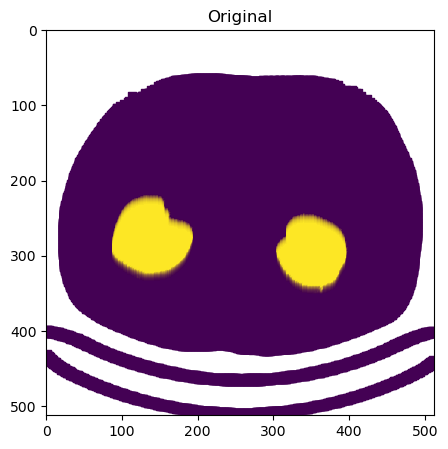

data_0_200/event_kits21_00039.npz


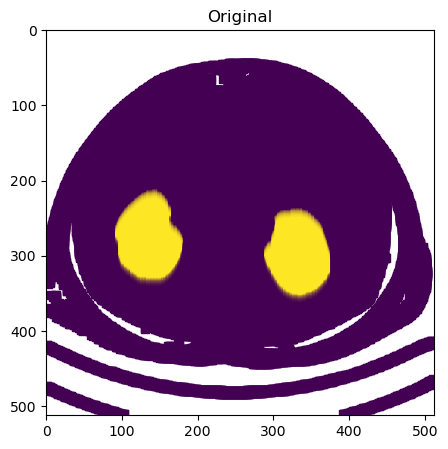

data_0_200/event_kits21_00040.npz


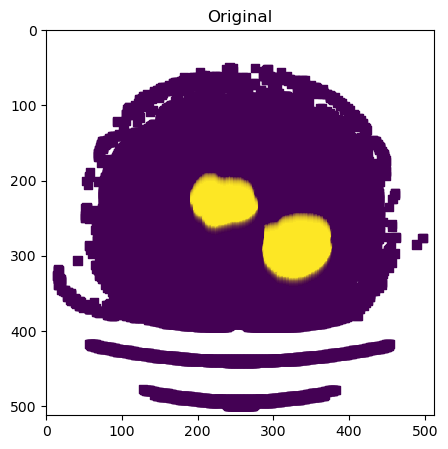

data_0_200/event_kits21_00041.npz


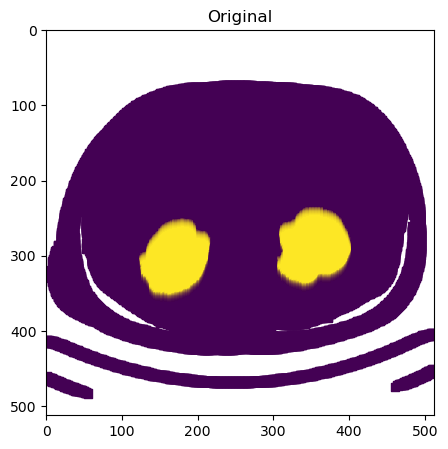

data_0_200/event_kits21_00042.npz


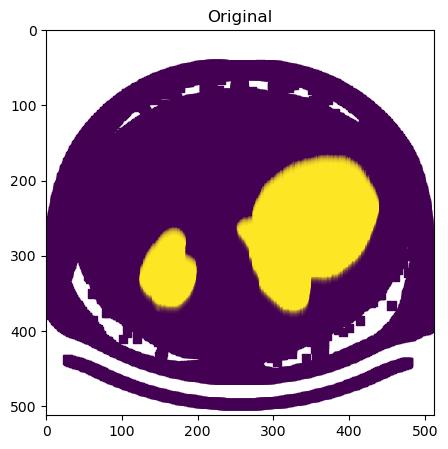

data_0_200/event_kits21_00043.npz


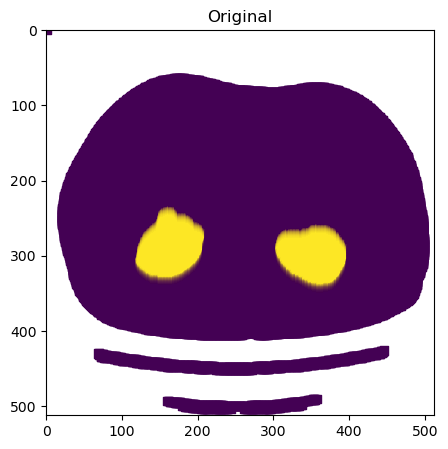

data_0_200/event_kits21_00044.npz


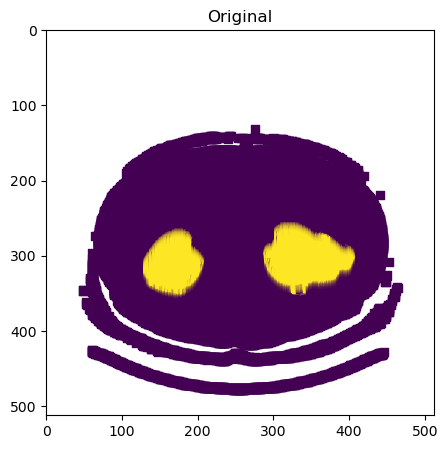

data_0_200/event_kits21_00045.npz


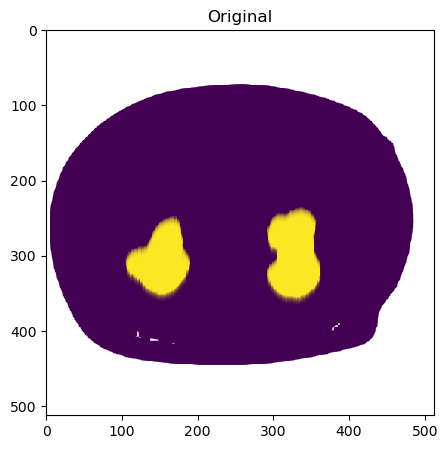

data_0_200/event_kits21_00046.npz


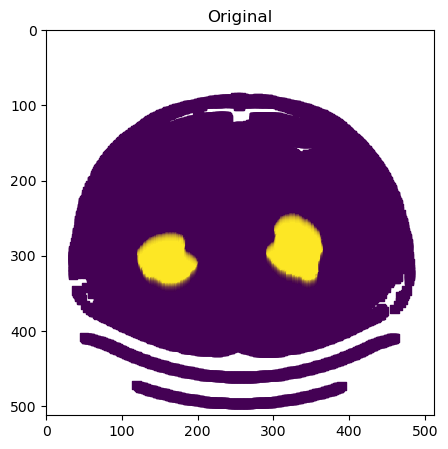

data_0_200/event_kits21_00047.npz


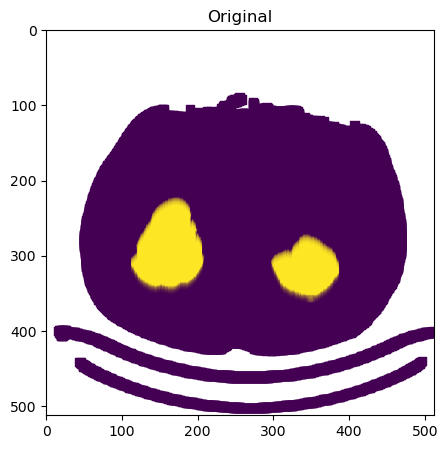

data_0_200/event_kits21_00048.npz


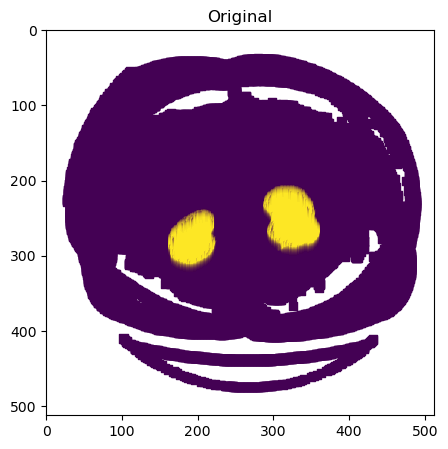

data_0_200/event_kits21_00049.npz


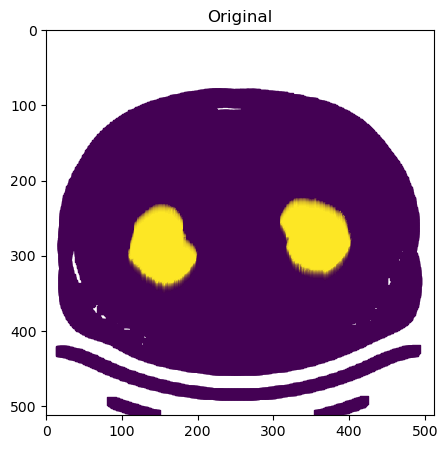

data_0_200/event_kits21_00050.npz


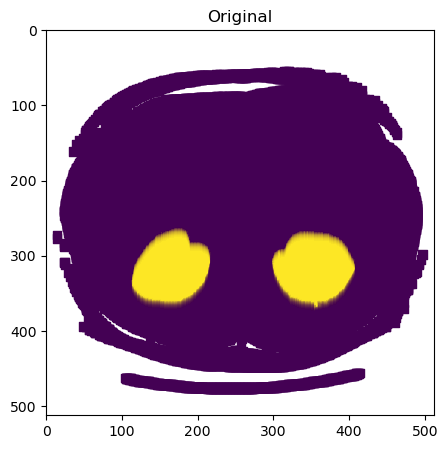

data_0_200/event_kits21_00051.npz


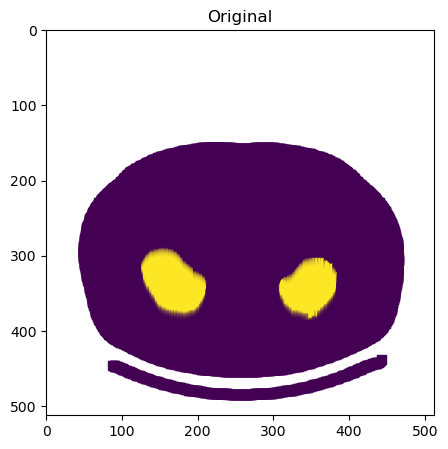

data_0_200/event_kits21_00052.npz


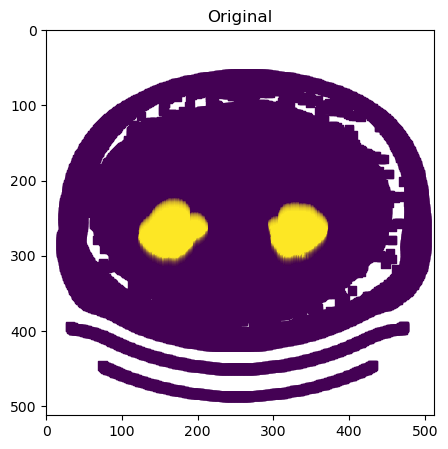

data_0_200/event_kits21_00053.npz


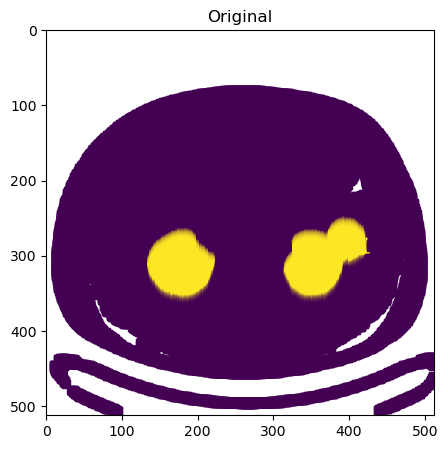

data_0_200/event_kits21_00054.npz


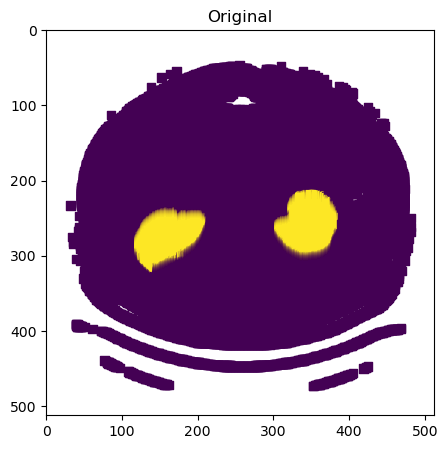

data_0_200/event_kits21_00055.npz


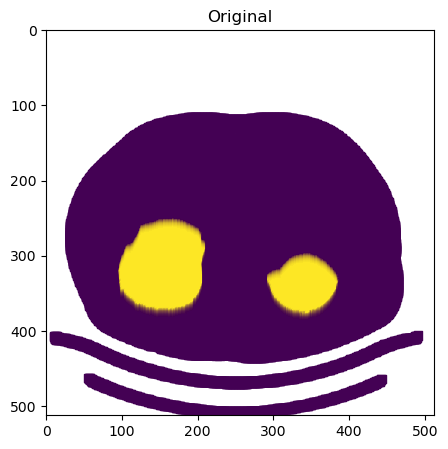

data_0_200/event_kits21_00056.npz


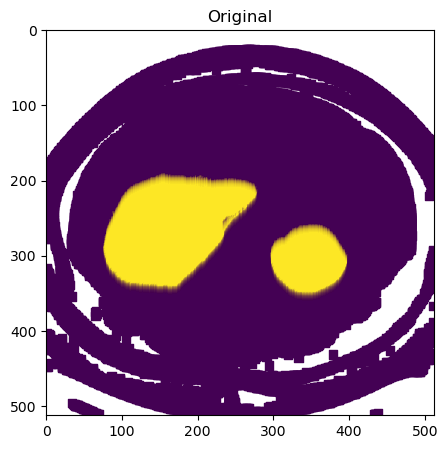

data_0_200/event_kits21_00057.npz


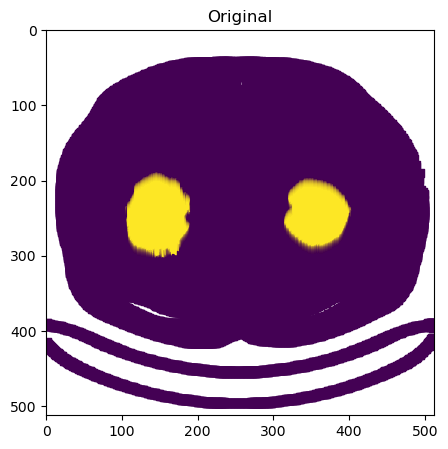

data_0_200/event_kits21_00058.npz


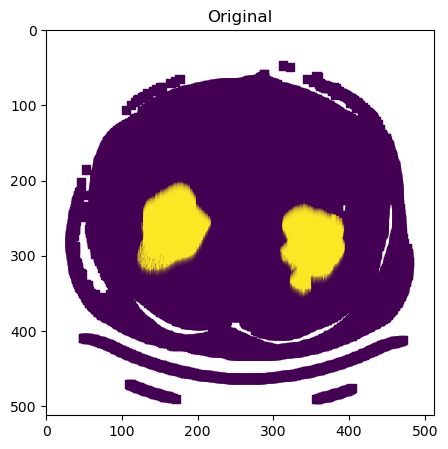

data_0_200/event_kits21_00059.npz


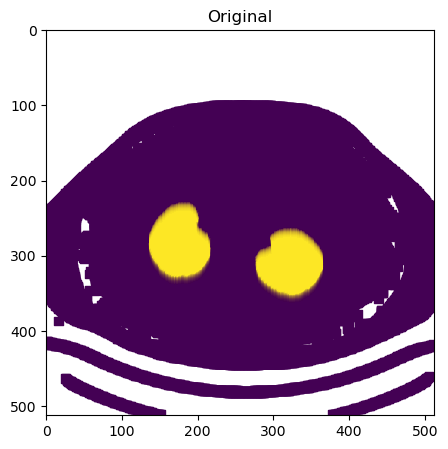

data_0_200/event_kits21_00060.npz


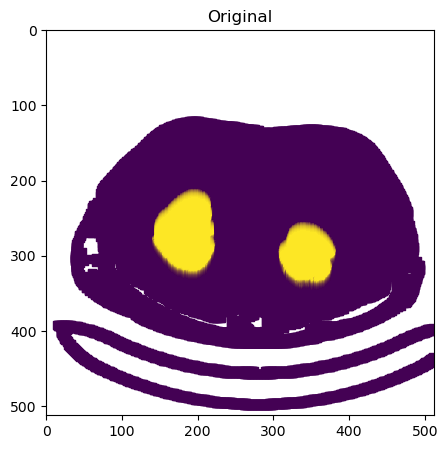

data_0_200/event_kits21_00061.npz


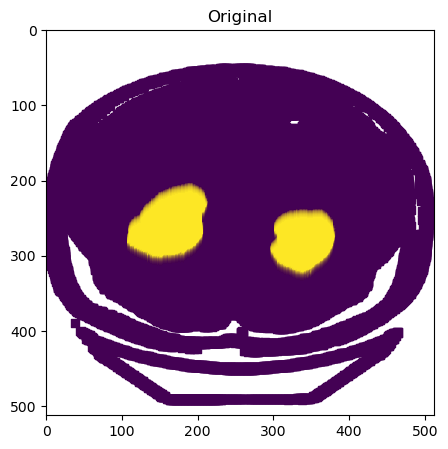

data_0_200/event_kits21_00062.npz


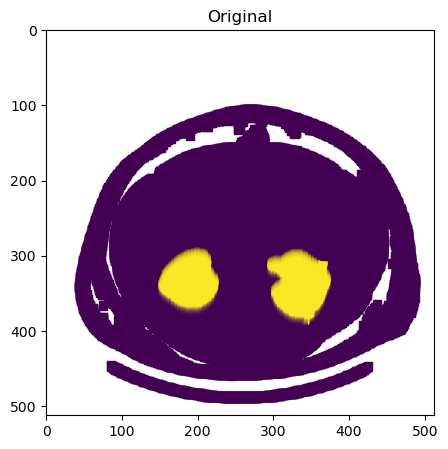

data_0_200/event_kits21_00063.npz


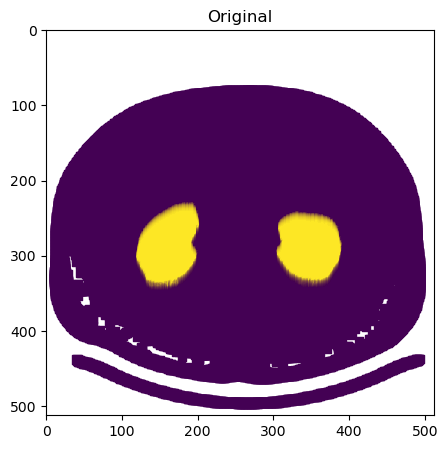

data_0_200/event_kits21_00064.npz


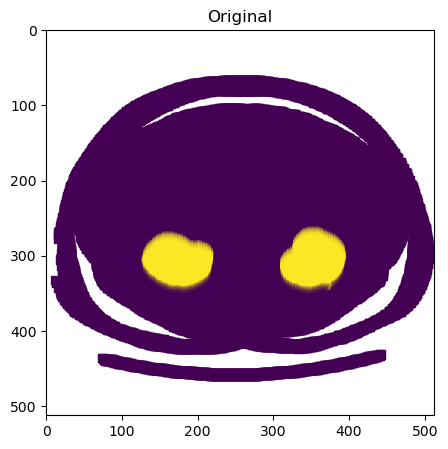

data_0_200/event_kits21_00065.npz


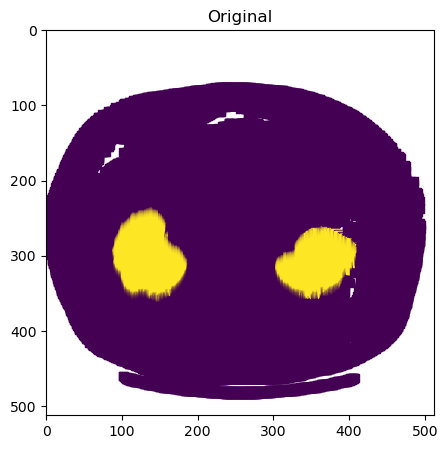

data_0_200/event_kits21_00066.npz


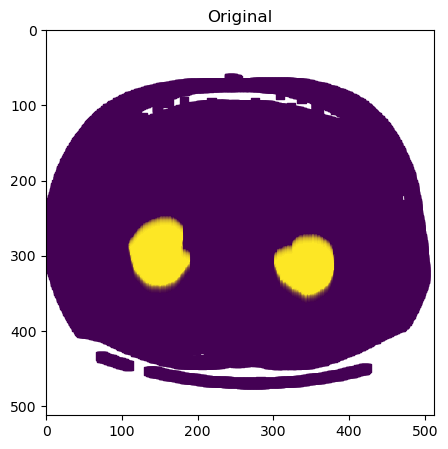

data_0_200/event_kits21_00067.npz


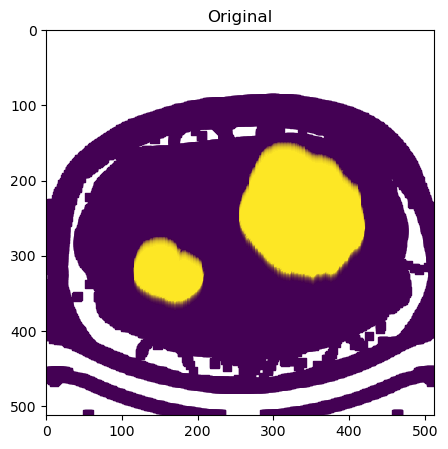

data_0_200/event_kits21_00068.npz


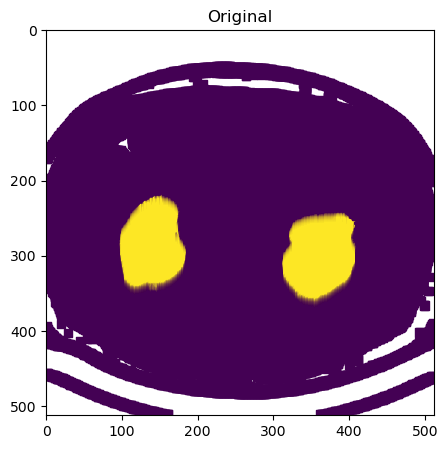

data_0_200/event_kits21_00069.npz


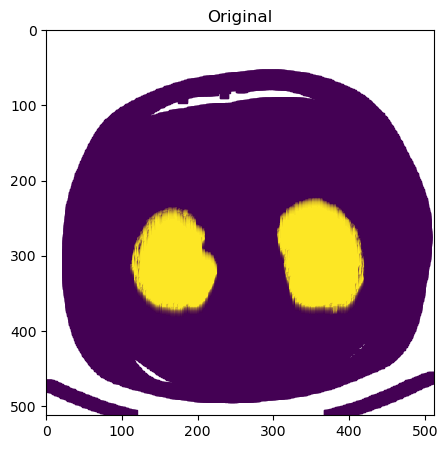

data_0_200/event_kits21_00070.npz


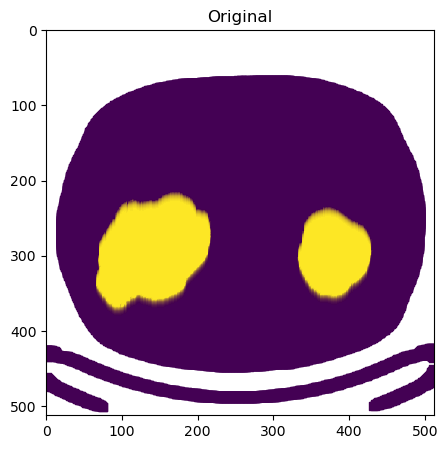

data_0_200/event_kits21_00071.npz


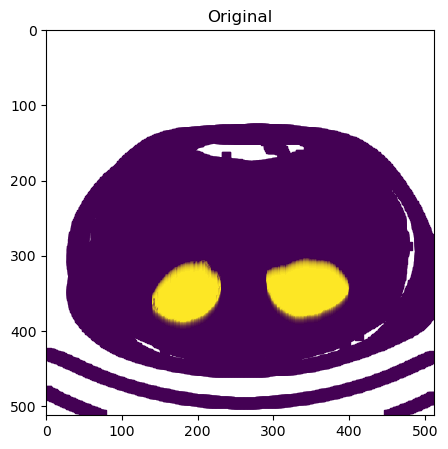

data_0_200/event_kits21_00072.npz


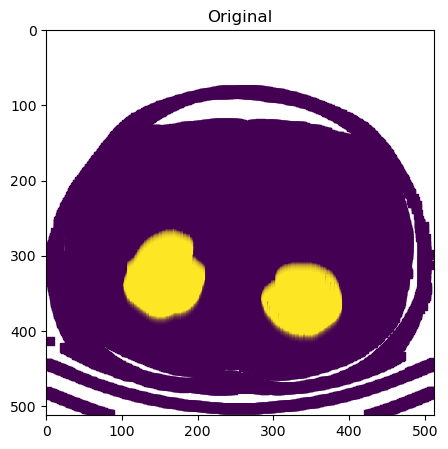

data_0_200/event_kits21_00073.npz


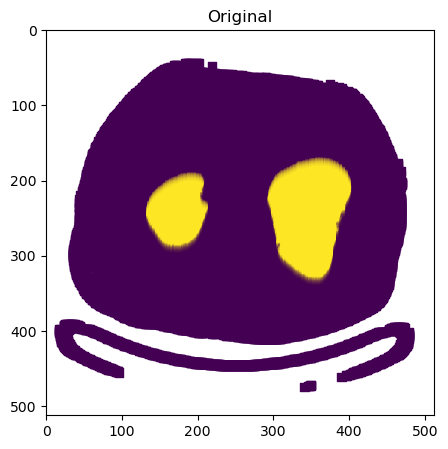

data_0_200/event_kits21_00074.npz


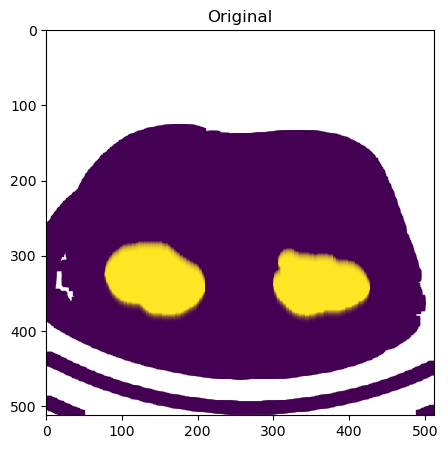

data_0_200/event_kits21_00075.npz


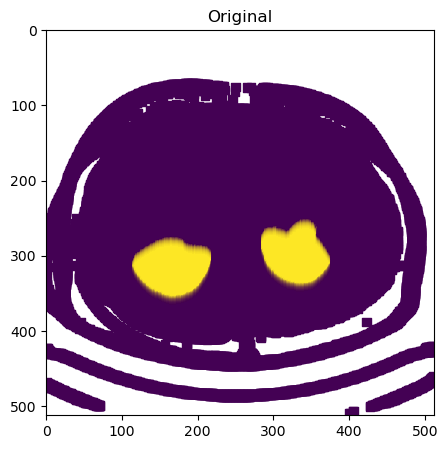

data_0_200/event_kits21_00076.npz


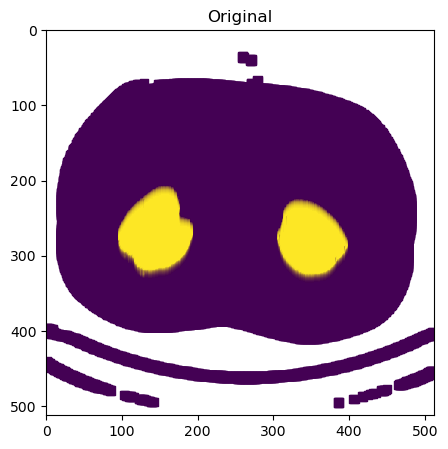

data_0_200/event_kits21_00077.npz


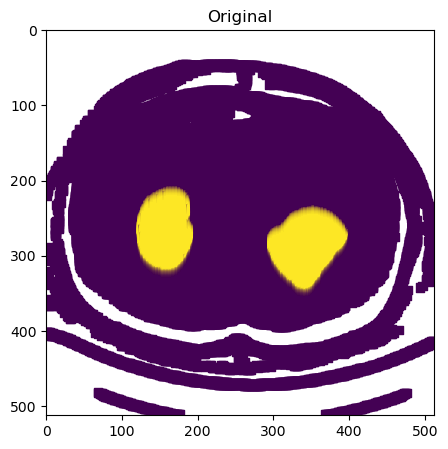

data_0_200/event_kits21_00078.npz


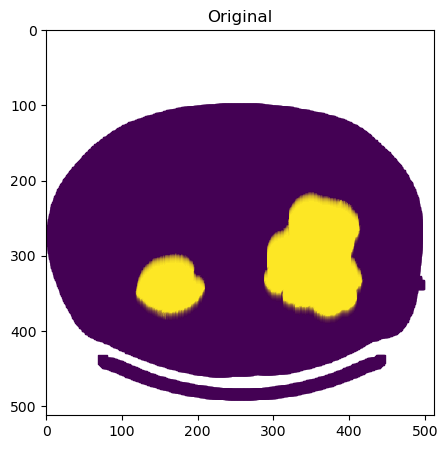

data_0_200/event_kits21_00079.npz


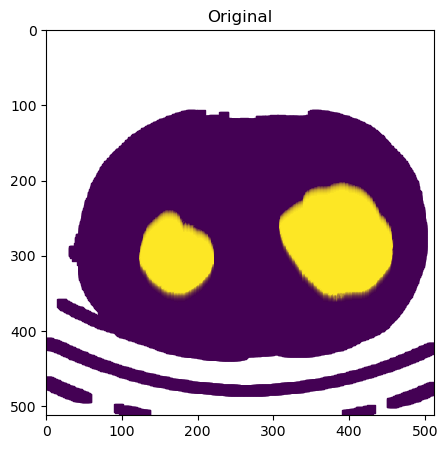

data_0_200/event_kits21_00080.npz


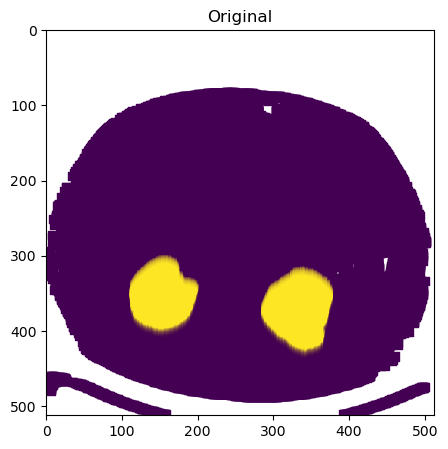

data_0_200/event_kits21_00081.npz


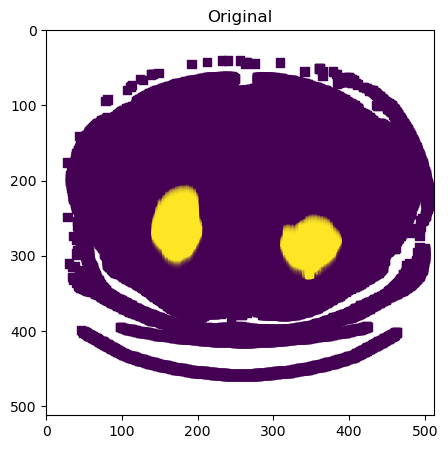

data_0_200/event_kits21_00082.npz


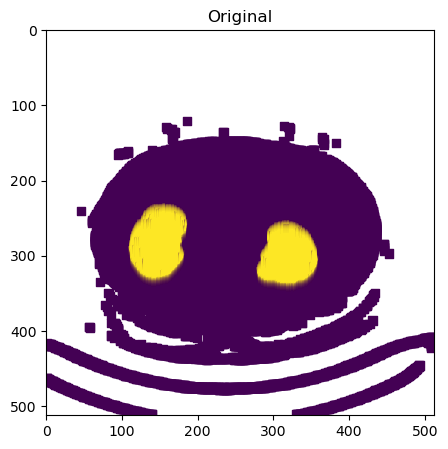

data_0_200/event_kits21_00083.npz


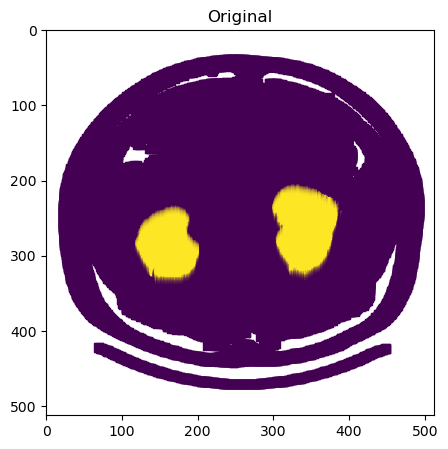

data_0_200/event_kits21_00084.npz


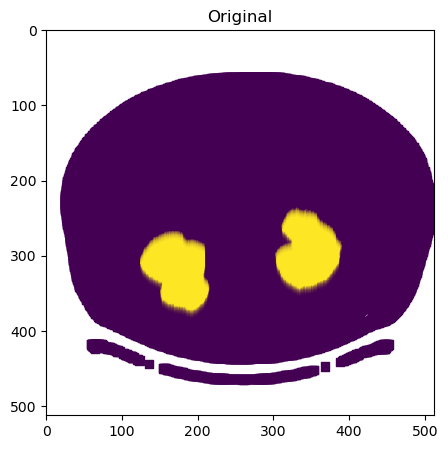

data_0_200/event_kits21_00085.npz


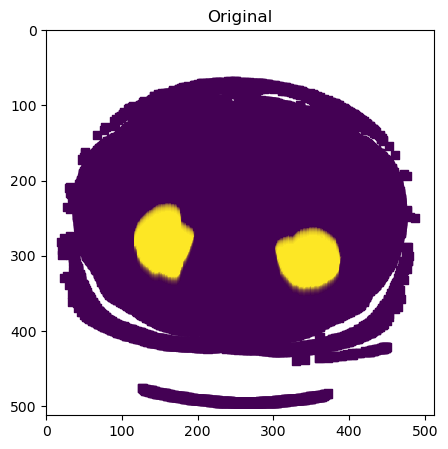

data_0_200/event_kits21_00086.npz


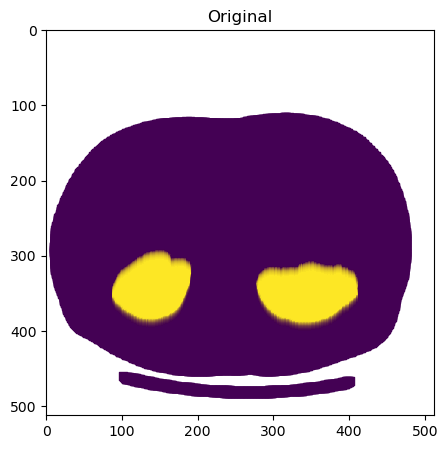

data_0_200/event_kits21_00087.npz


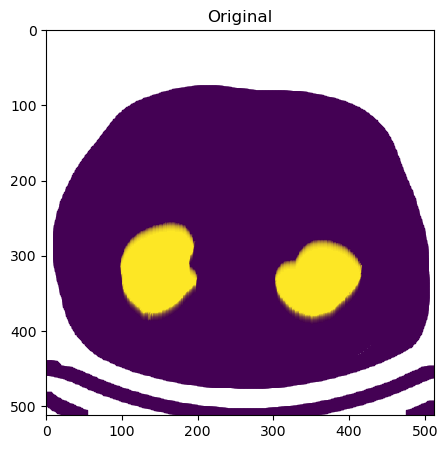

data_0_200/event_kits21_00088.npz


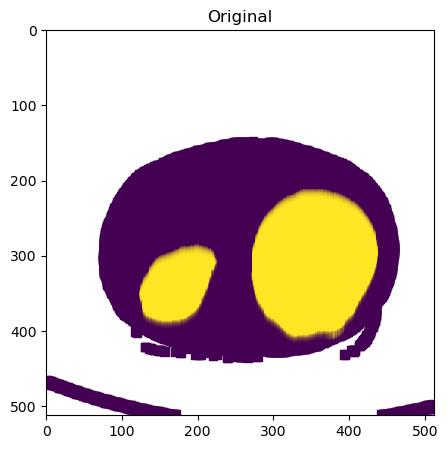

data_0_200/event_kits21_00089.npz


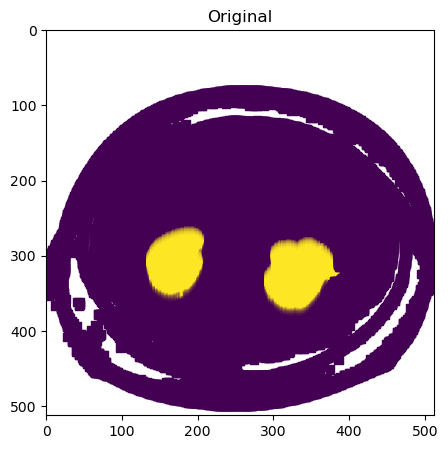

data_0_200/event_kits21_00090.npz


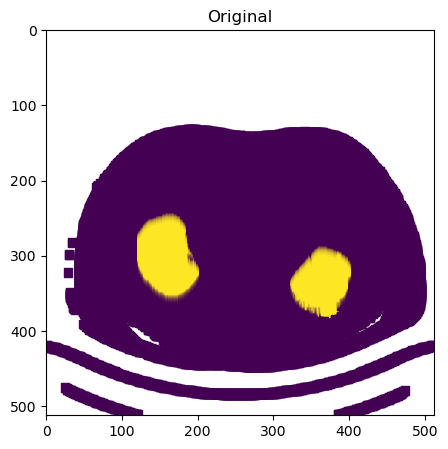

data_0_200/event_kits21_00091.npz


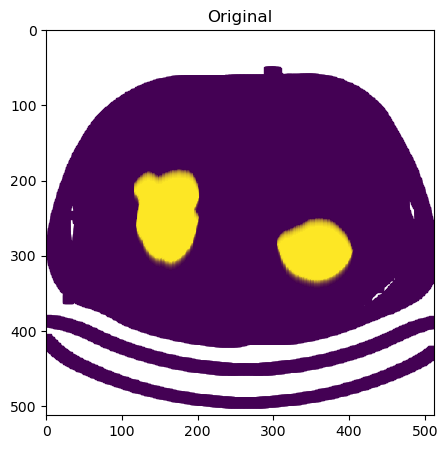

data_0_200/event_kits21_00092.npz


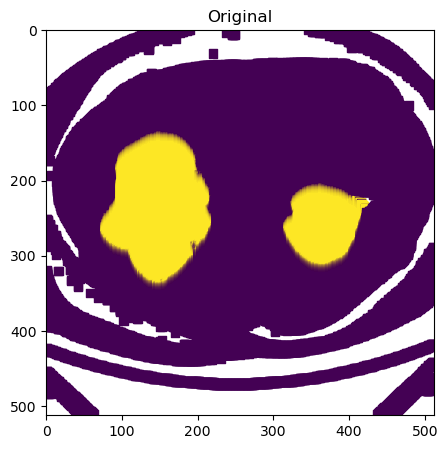

data_0_200/event_kits21_00093.npz


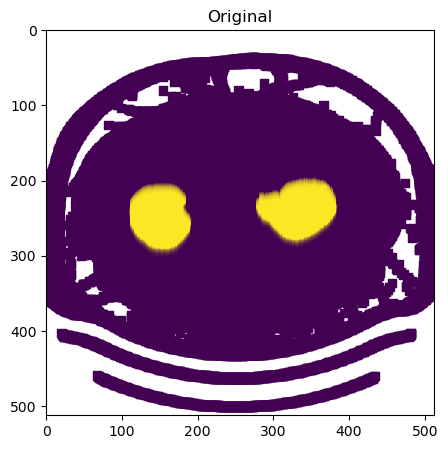

data_0_200/event_kits21_00094.npz


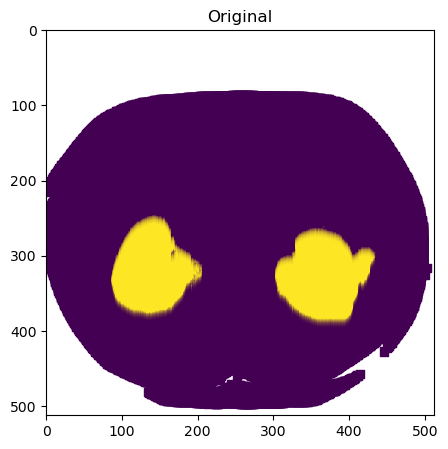

data_0_200/event_kits21_00095.npz


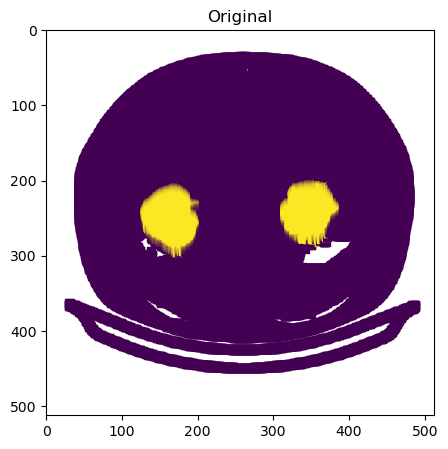

data_0_200/event_kits21_00096.npz


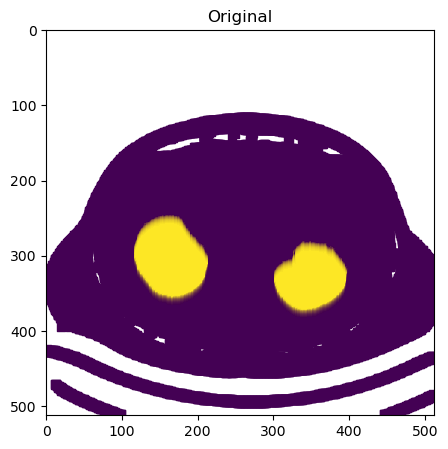

data_0_200/event_kits21_00097.npz


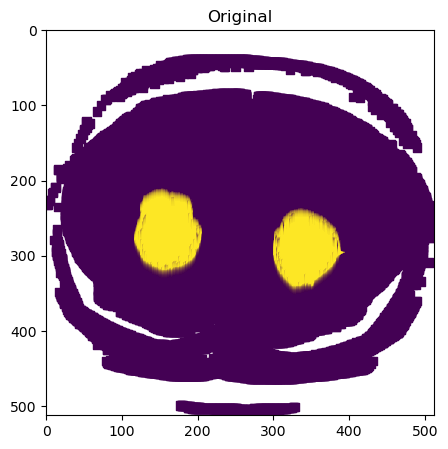

data_0_200/event_kits21_00098.npz


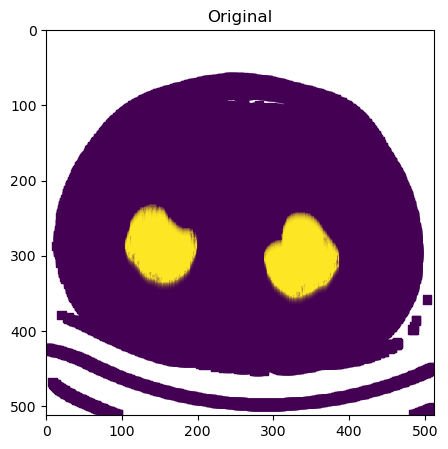

data_0_200/event_kits21_00099.npz


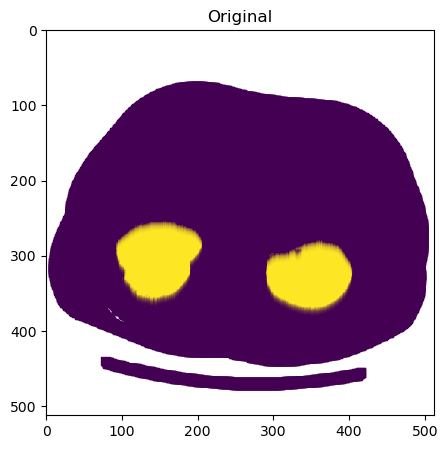

data_0_200/event_kits21_00100.npz


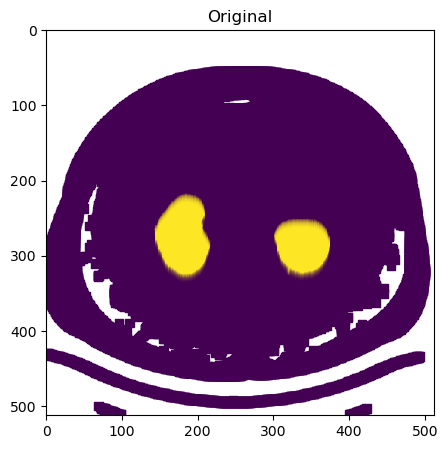

data_0_200/event_kits21_00101.npz


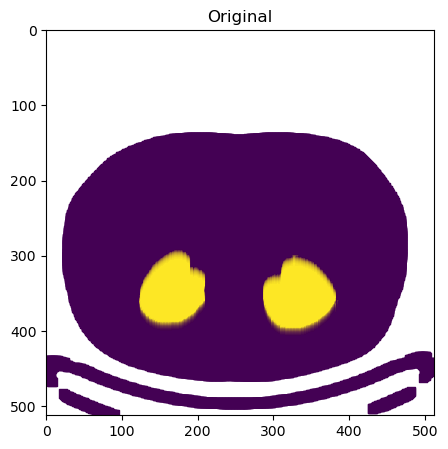

data_0_200/event_kits21_00102.npz


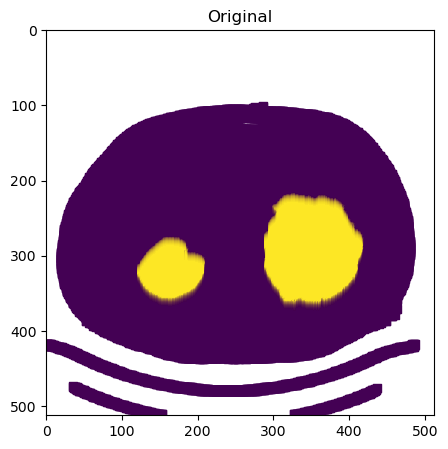

data_0_200/event_kits21_00103.npz


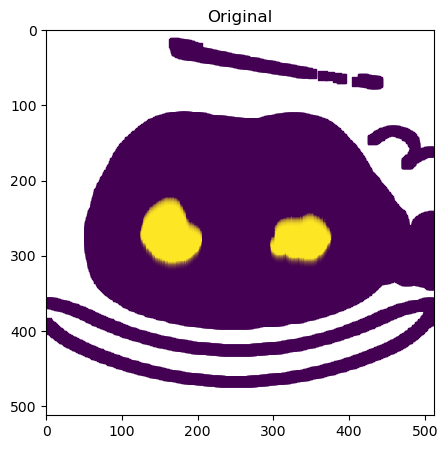

data_0_200/event_kits21_00104.npz


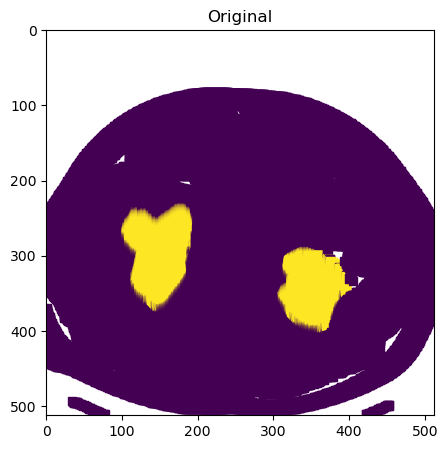

data_0_200/event_kits21_00105.npz


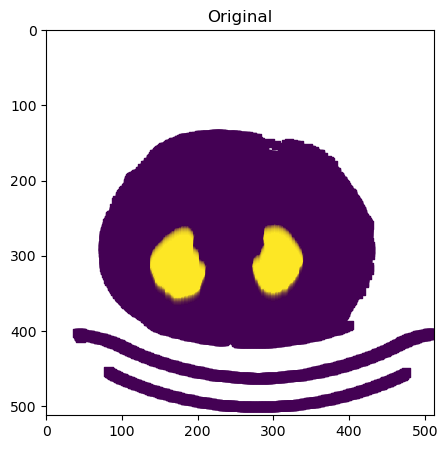

data_0_200/event_kits21_00106.npz


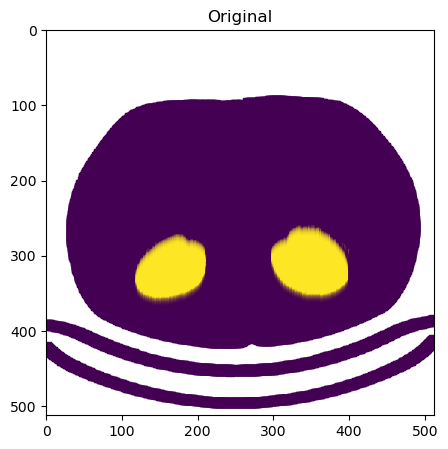

data_0_200/event_kits21_00107.npz


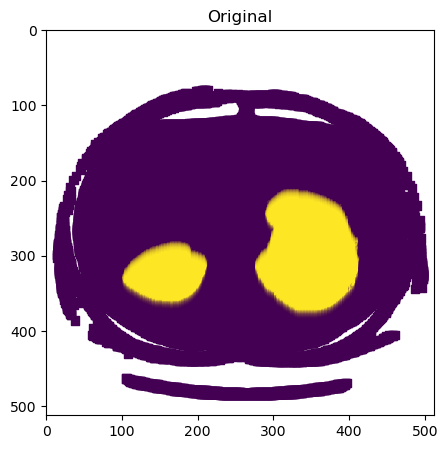

data_0_200/event_kits21_00108.npz


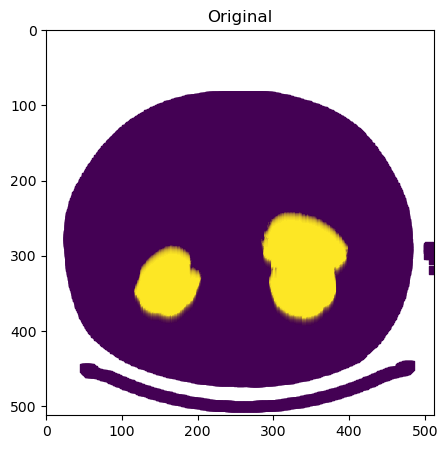

data_0_200/event_kits21_00109.npz


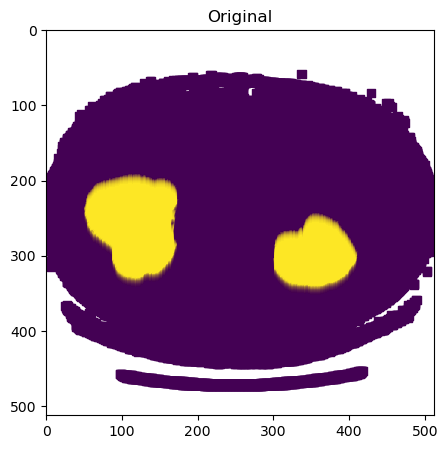

data_0_200/event_kits21_00110.npz


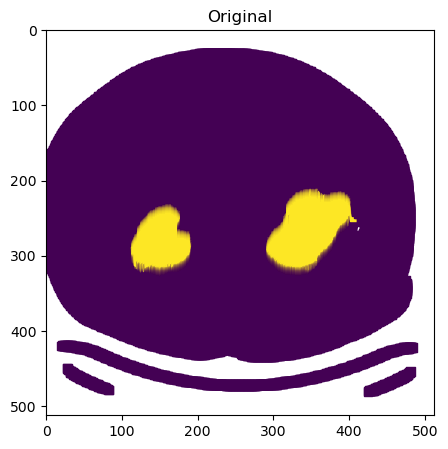

data_0_200/event_kits21_00111.npz


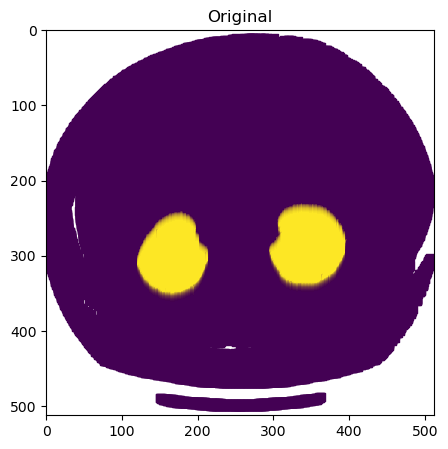

data_0_200/event_kits21_00112.npz


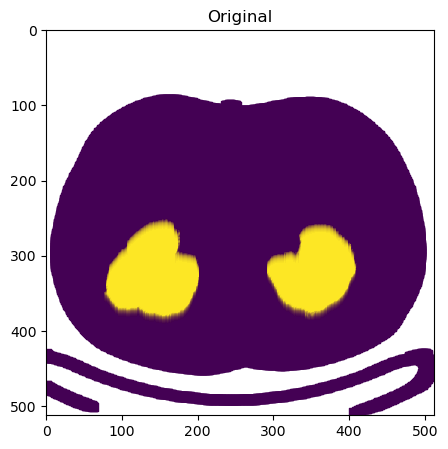

data_0_200/event_kits21_00113.npz


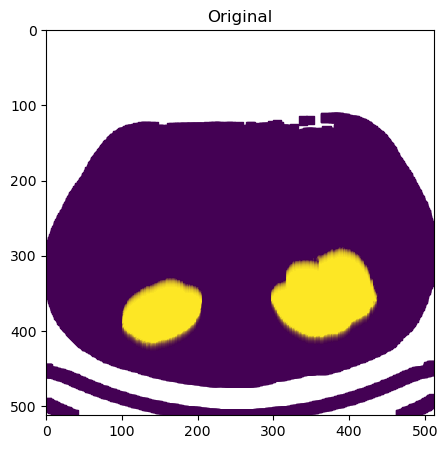

data_0_200/event_kits21_00114.npz


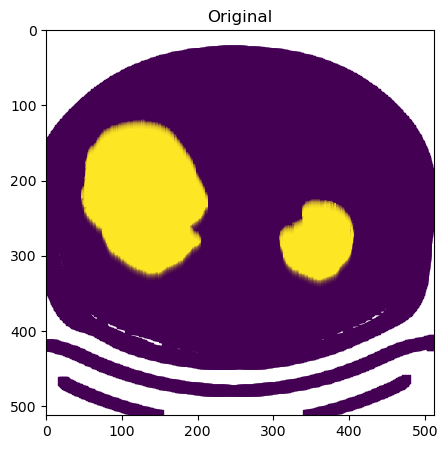

data_0_200/event_kits21_00115.npz


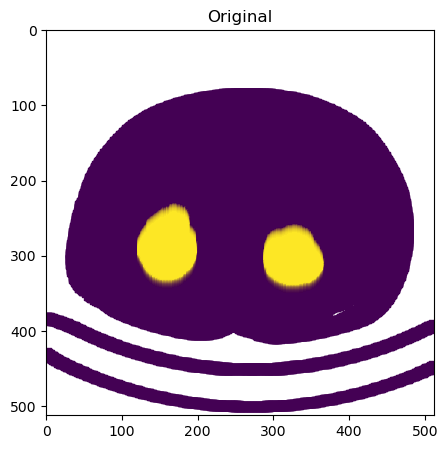

data_0_200/event_kits21_00116.npz


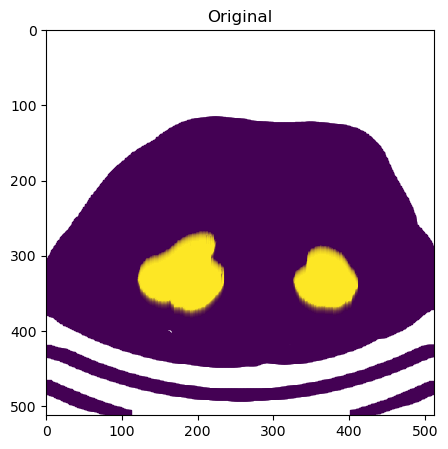

data_0_200/event_kits21_00117.npz


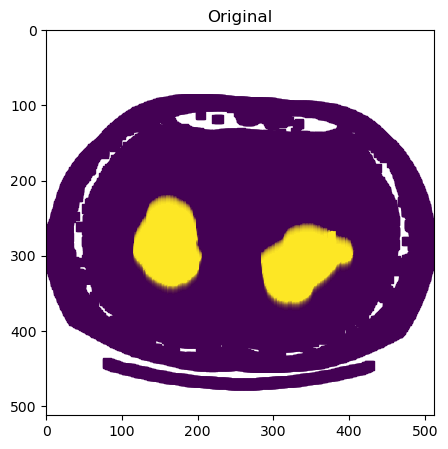

data_0_200/event_kits21_00118.npz


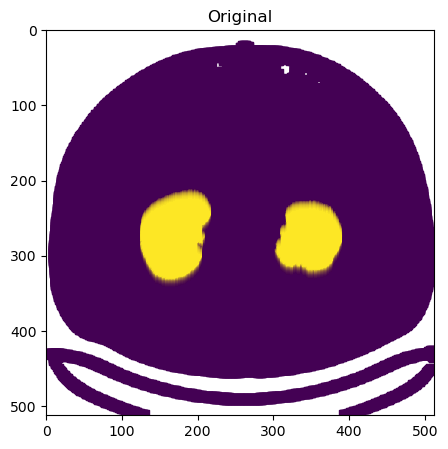

data_0_200/event_kits21_00119.npz


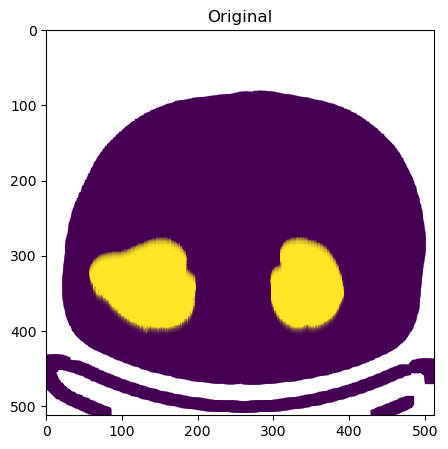

data_0_200/event_kits21_00120.npz


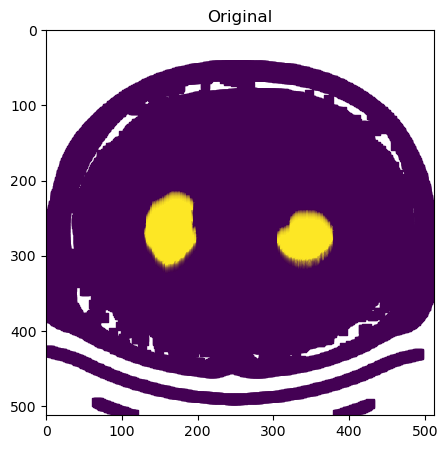

data_0_200/event_kits21_00121.npz


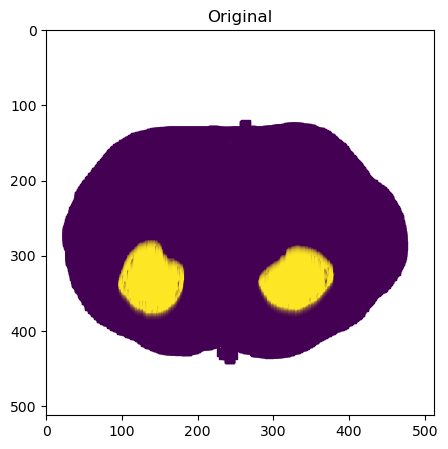

data_0_200/event_kits21_00122.npz


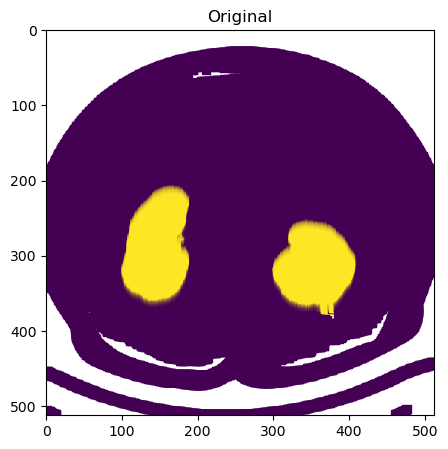

data_0_200/event_kits21_00123.npz


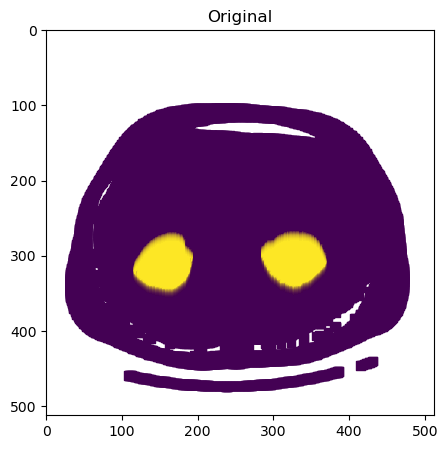

data_0_200/event_kits21_00124.npz


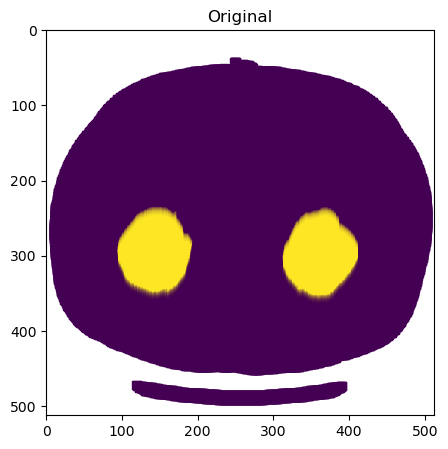

data_0_200/event_kits21_00125.npz


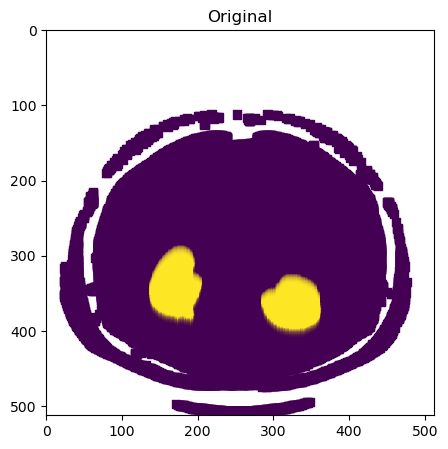

data_0_200/event_kits21_00126.npz


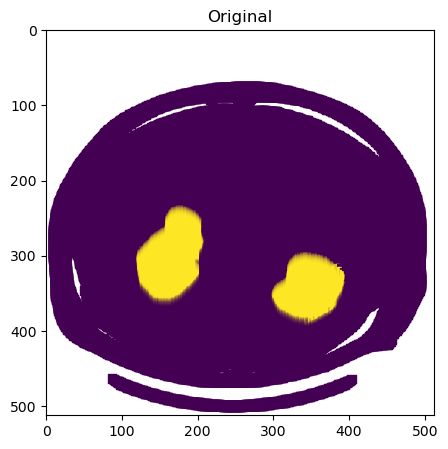

data_0_200/event_kits21_00127.npz


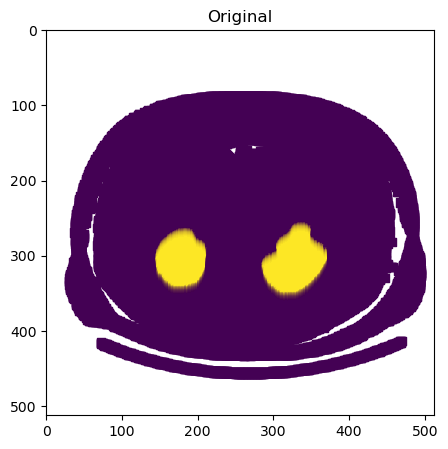

data_0_200/event_kits21_00128.npz


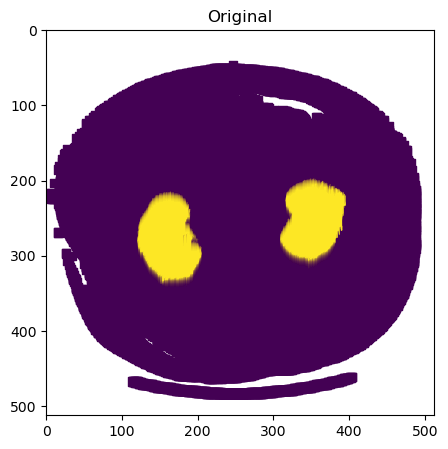

data_0_200/event_kits21_00129.npz


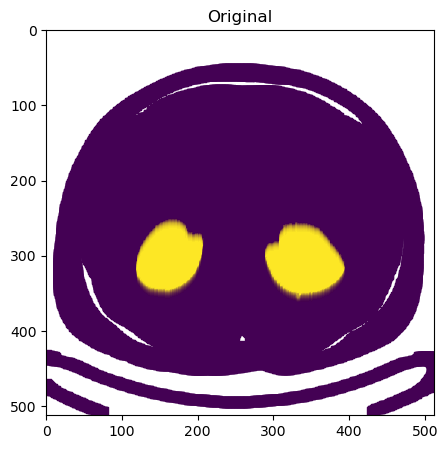

data_0_200/event_kits21_00130.npz


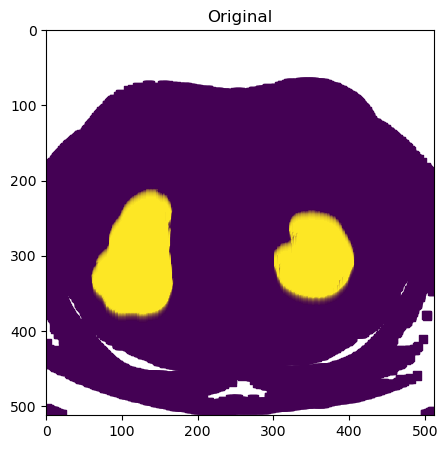

data_0_200/event_kits21_00131.npz


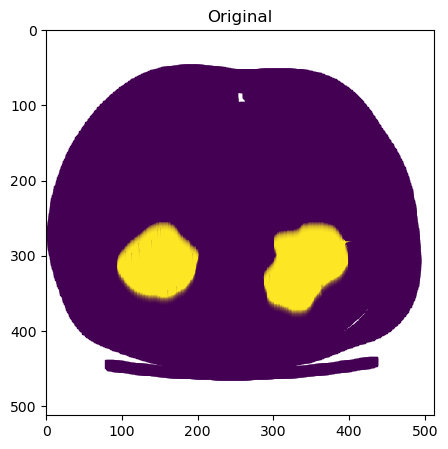

data_0_200/event_kits21_00132.npz


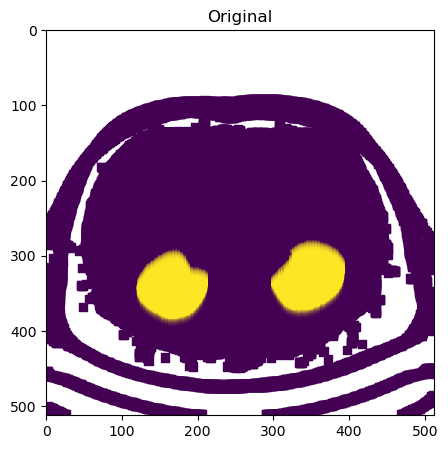

data_0_200/event_kits21_00133.npz


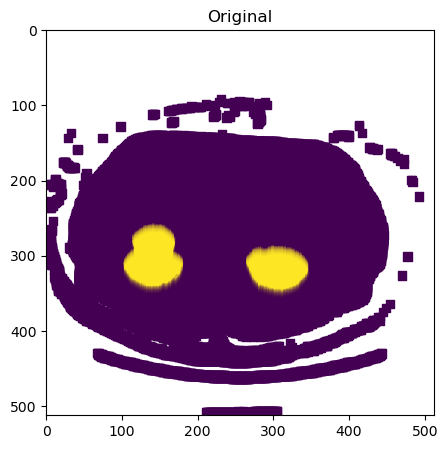

data_0_200/event_kits21_00134.npz


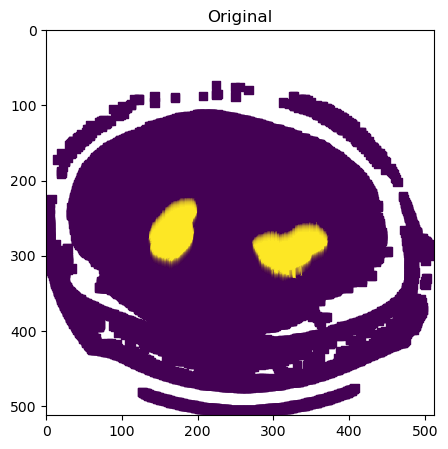

data_0_200/event_kits21_00135.npz


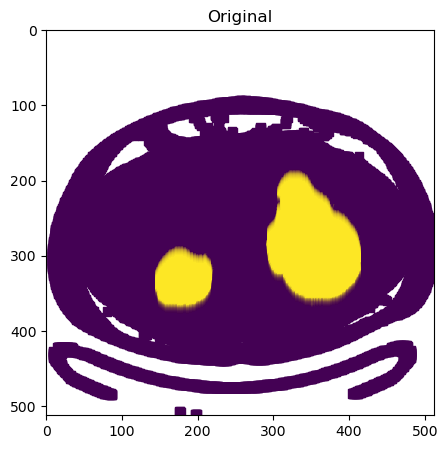

data_0_200/event_kits21_00136.npz


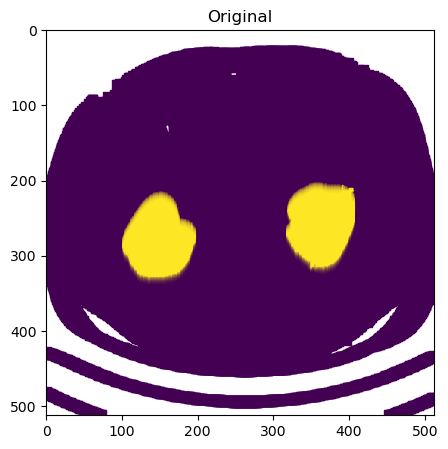

data_0_200/event_kits21_00137.npz


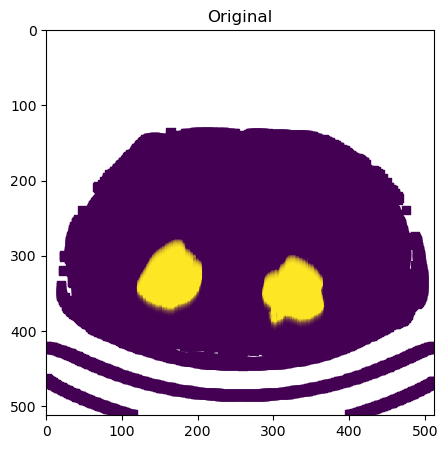

data_0_200/event_kits21_00138.npz


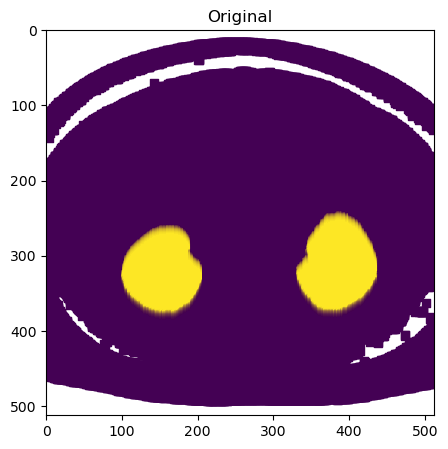

data_0_200/event_kits21_00139.npz


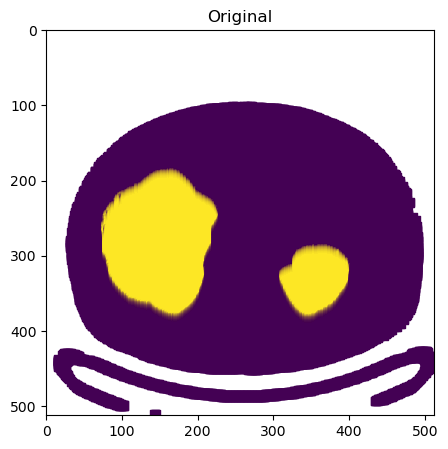

data_0_200/event_kits21_00140.npz


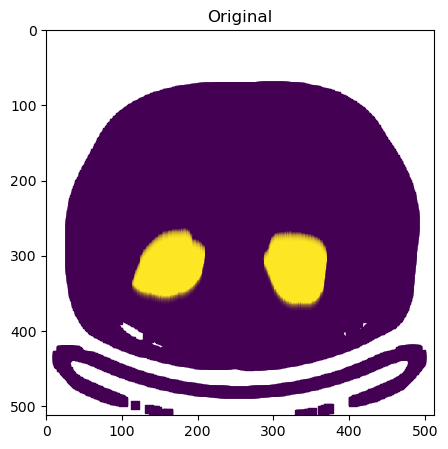

data_0_200/event_kits21_00141.npz


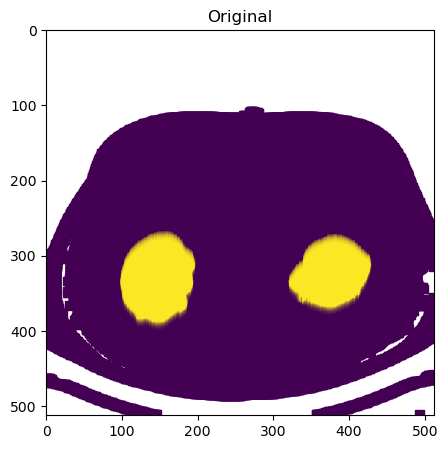

data_0_200/event_kits21_00142.npz


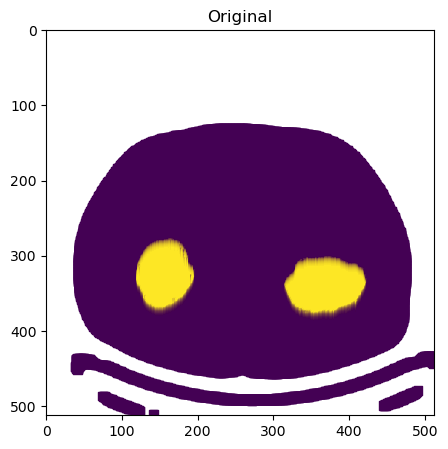

data_0_200/event_kits21_00143.npz


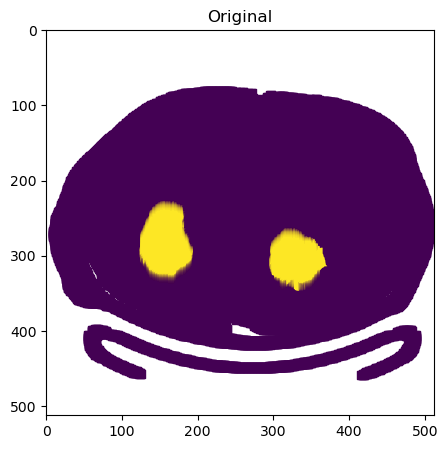

data_0_200/event_kits21_00144.npz


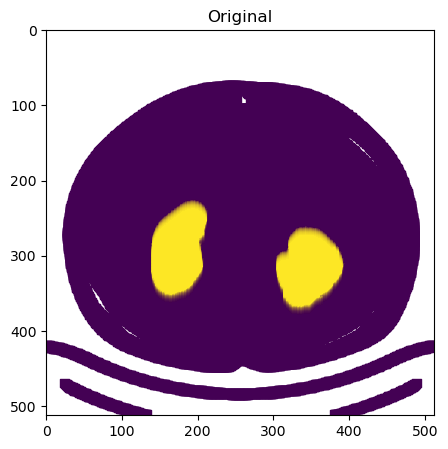

data_0_200/event_kits21_00145.npz


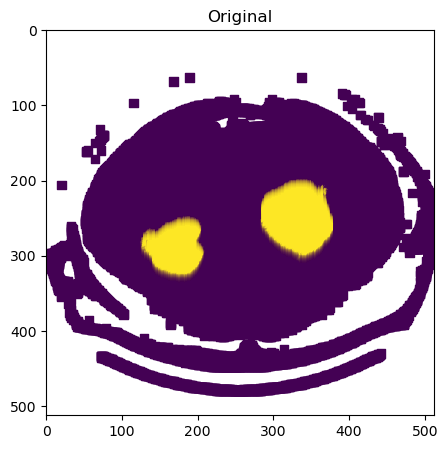

data_0_200/event_kits21_00146.npz


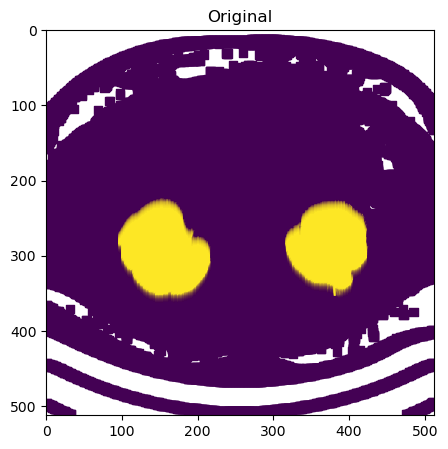

data_0_200/event_kits21_00147.npz


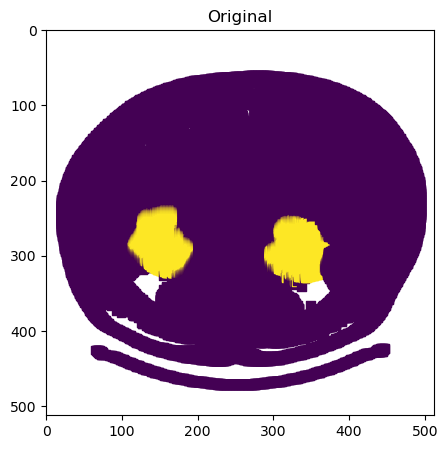

data_0_200/event_kits21_00148.npz


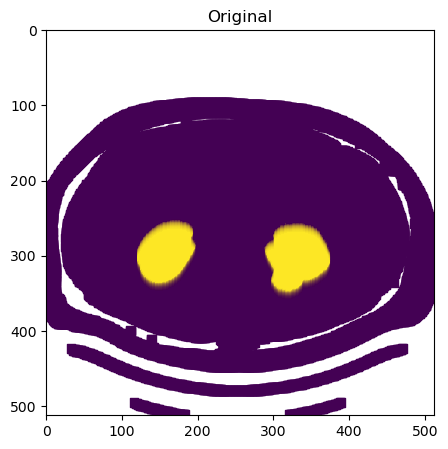

data_0_200/event_kits21_00149.npz


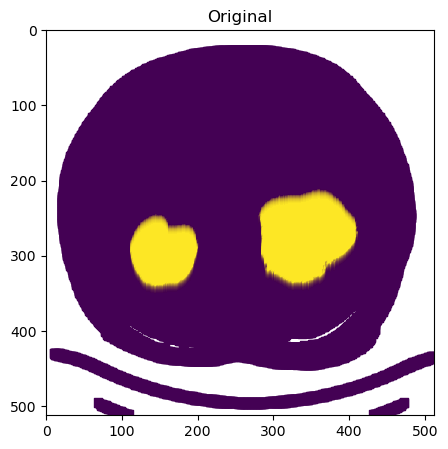

data_0_200/event_kits21_00150.npz


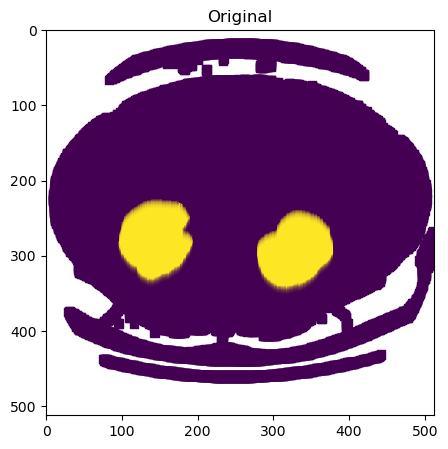

data_0_200/event_kits21_00151.npz


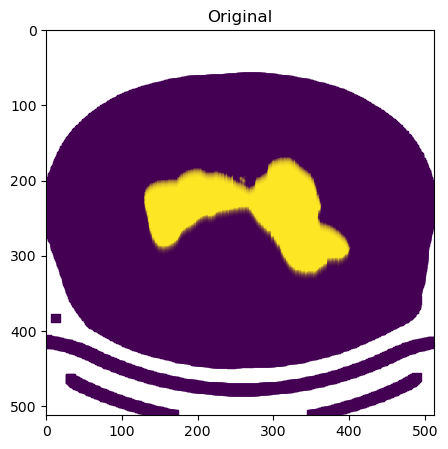

data_0_200/event_kits21_00152.npz


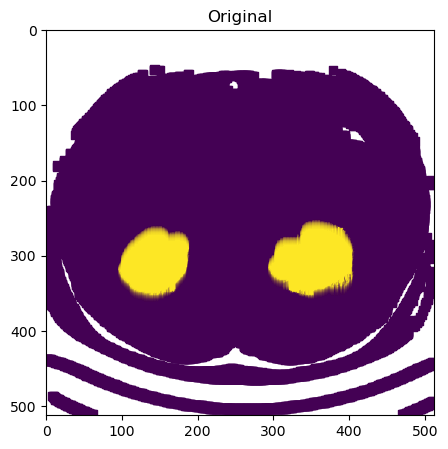

data_0_200/event_kits21_00153.npz


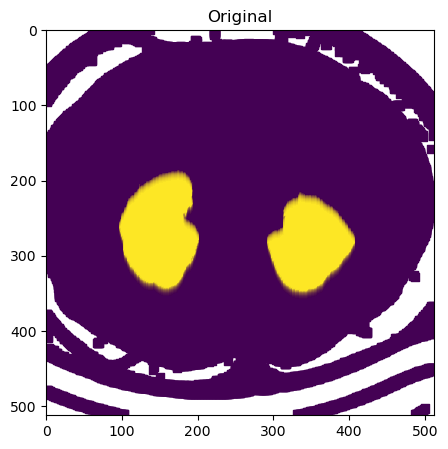

data_0_200/event_kits21_00154.npz


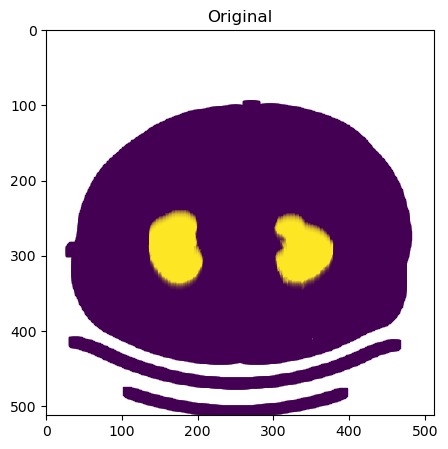

data_0_200/event_kits21_00155.npz


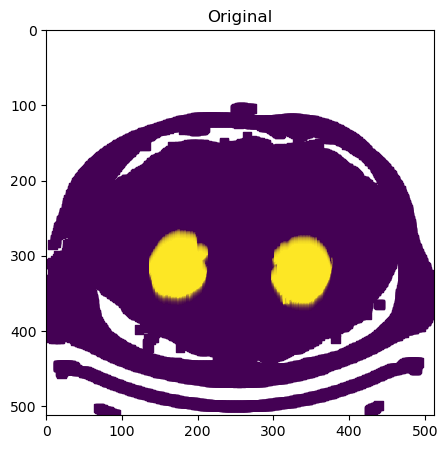

data_0_200/event_kits21_00156.npz


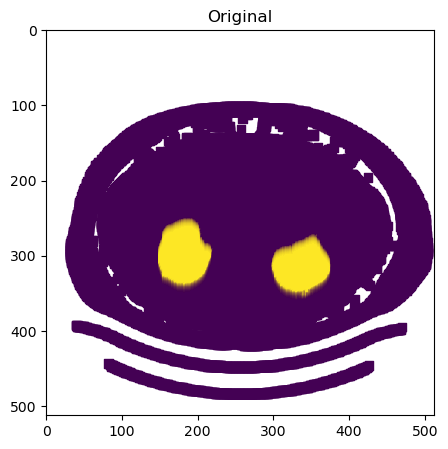

data_0_200/event_kits21_00157.npz


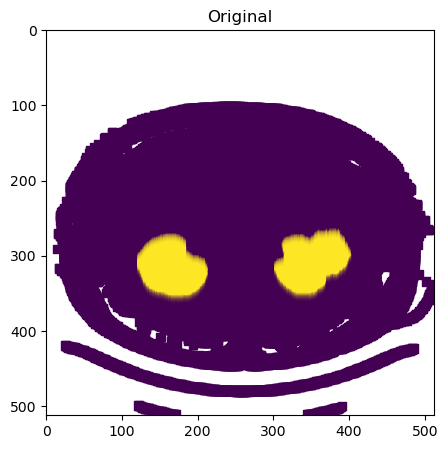

data_0_200/event_kits21_00158.npz


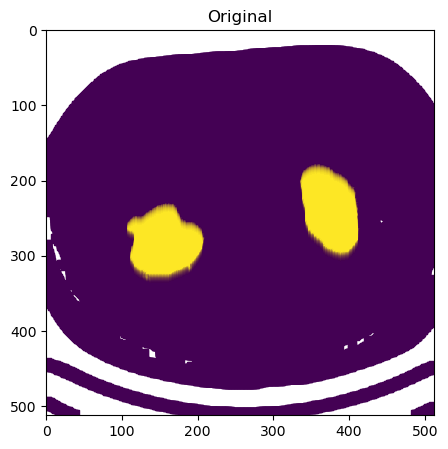

data_0_200/event_kits21_00159.npz


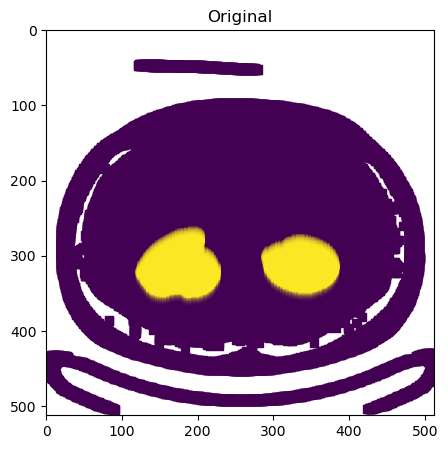

data_0_200/event_kits21_00160.npz


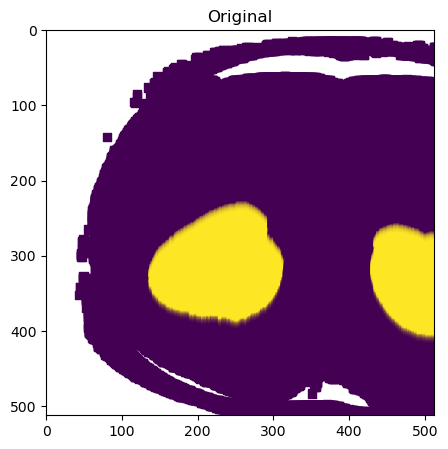

data_0_200/event_kits21_00161.npz


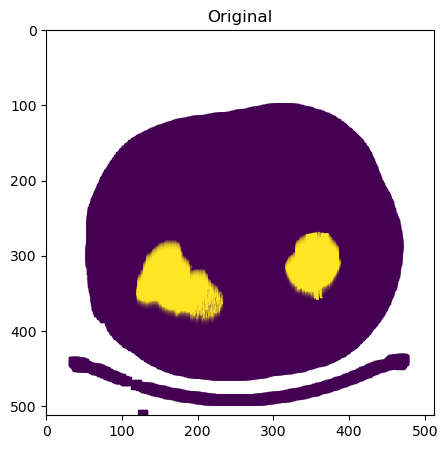

data_0_200/event_kits21_00162.npz


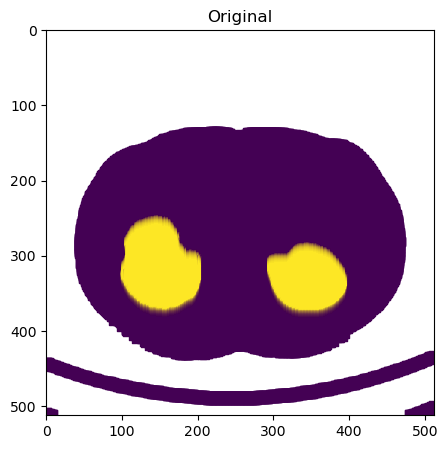

data_0_200/event_kits21_00163.npz


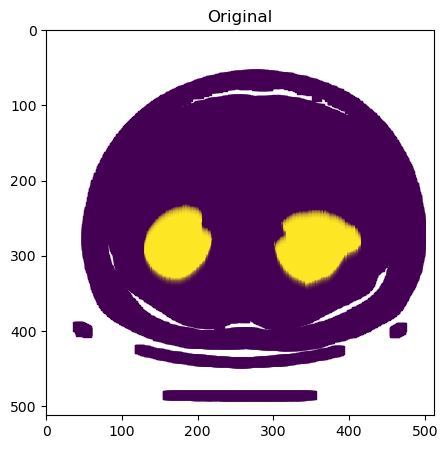

data_0_200/event_kits21_00164.npz


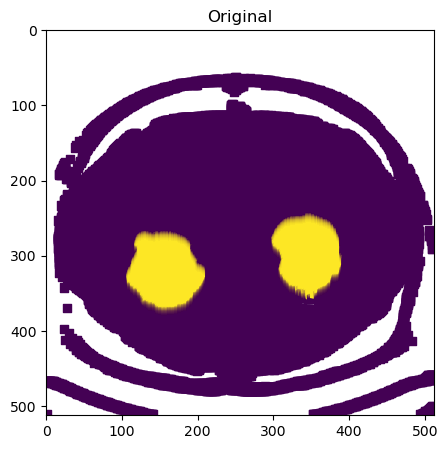

data_0_200/event_kits21_00165.npz


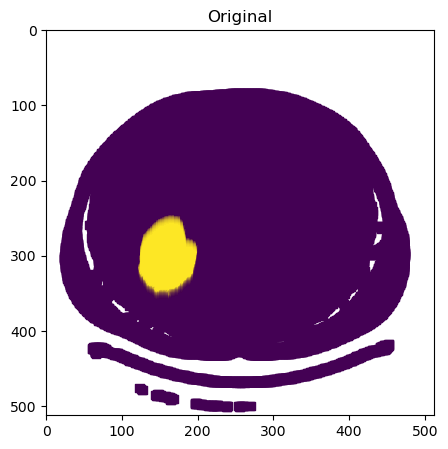

data_0_200/event_kits21_00166.npz


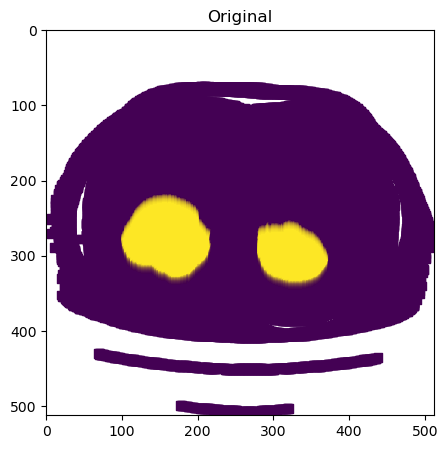

data_0_200/event_kits21_00167.npz


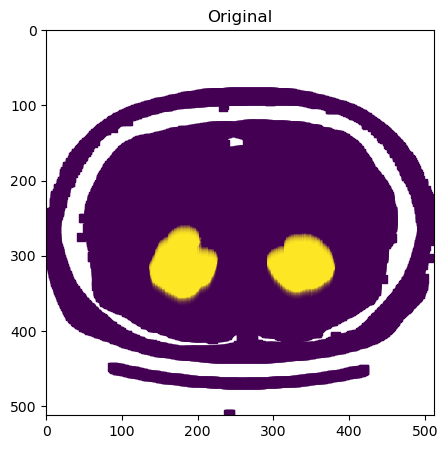

data_0_200/event_kits21_00168.npz


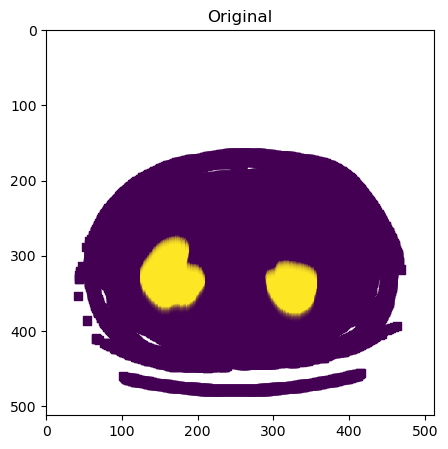

data_0_200/event_kits21_00169.npz


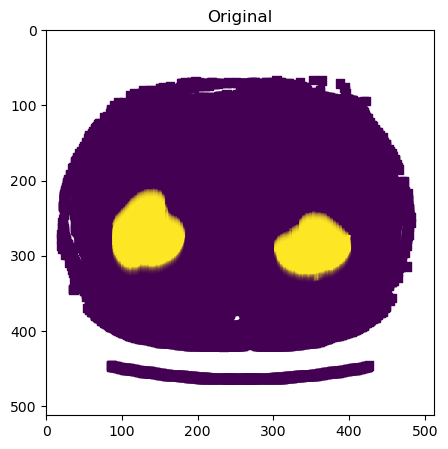

data_0_200/event_kits21_00170.npz


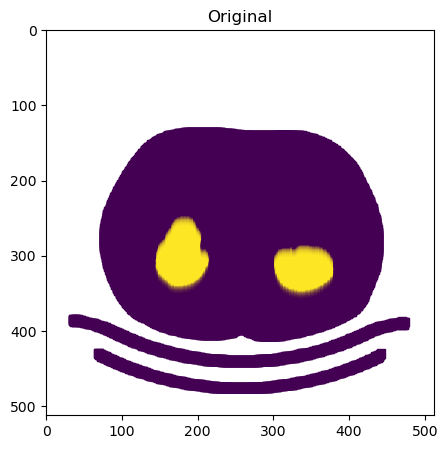

data_0_200/event_kits21_00171.npz


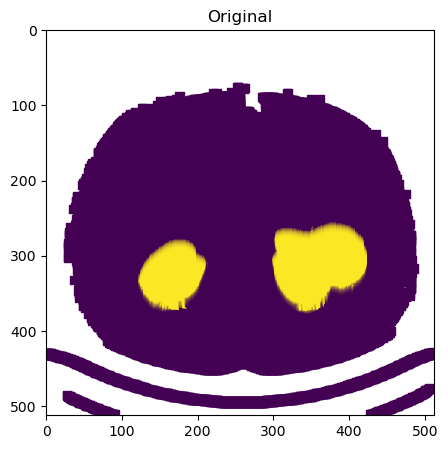

data_0_200/event_kits21_00172.npz


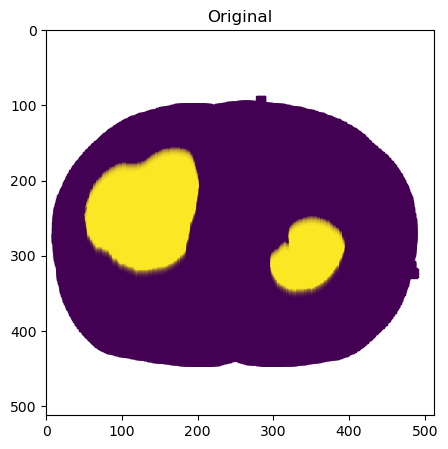

data_0_200/event_kits21_00173.npz


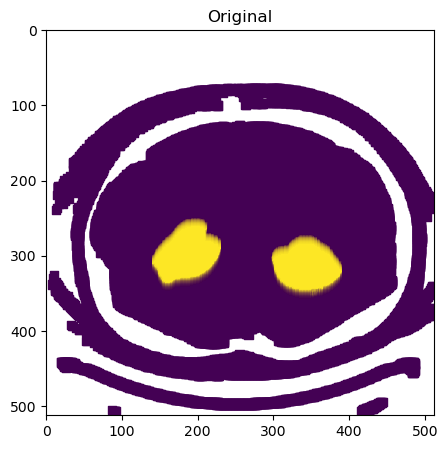

data_0_200/event_kits21_00174.npz


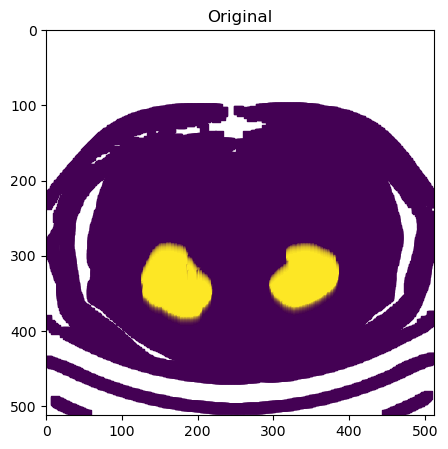

data_0_200/event_kits21_00175.npz


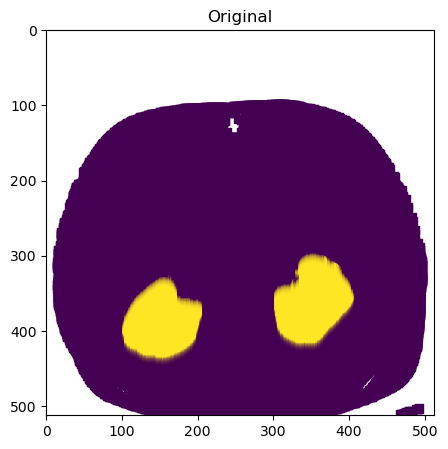

data_0_200/event_kits21_00176.npz


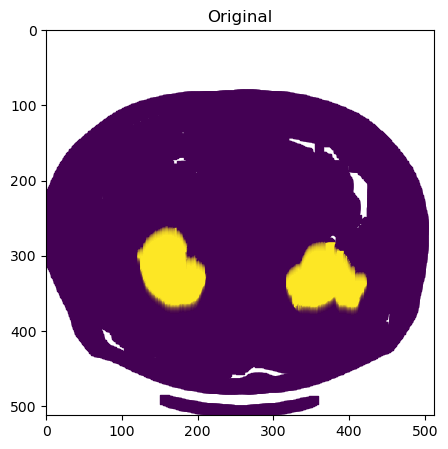

data_0_200/event_kits21_00177.npz


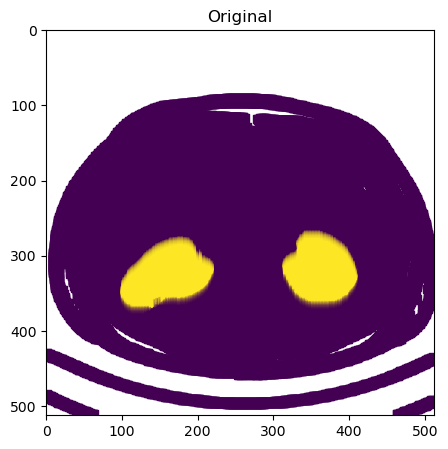

data_0_200/event_kits21_00178.npz


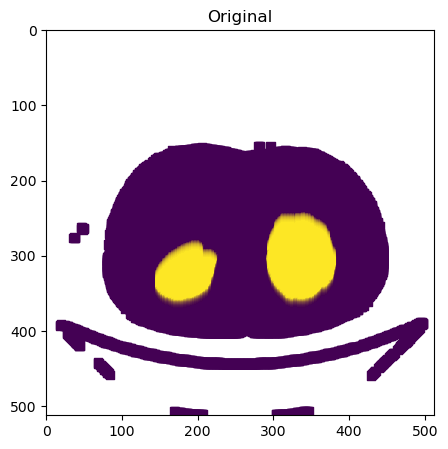

data_0_200/event_kits21_00179.npz


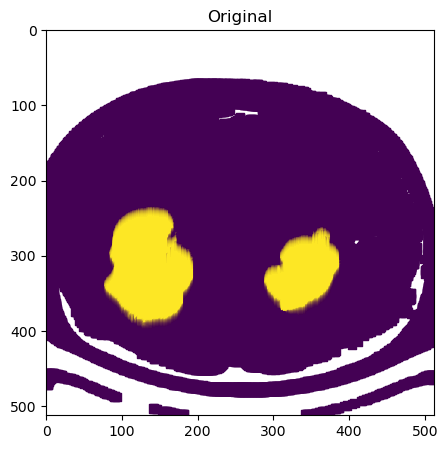

data_0_200/event_kits21_00180.npz


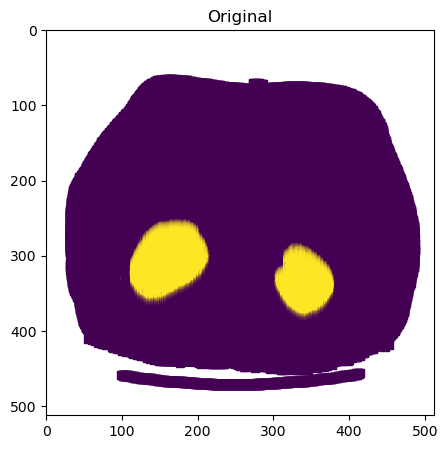

data_0_200/event_kits21_00181.npz


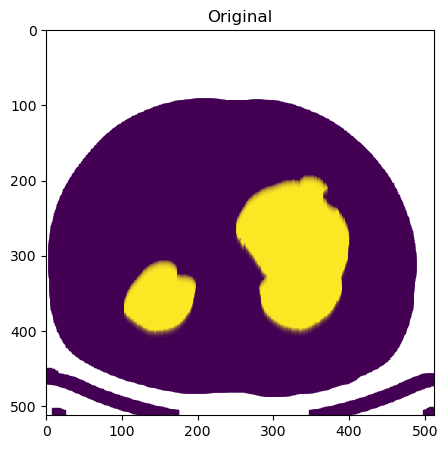

data_0_200/event_kits21_00182.npz


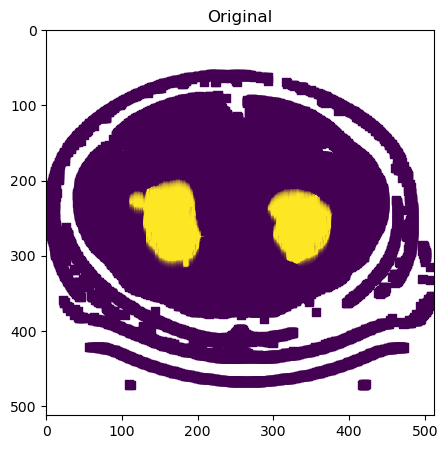

data_0_200/event_kits21_00183.npz


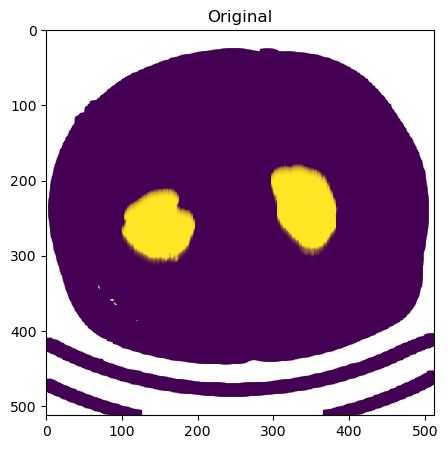

data_0_200/event_kits21_00184.npz


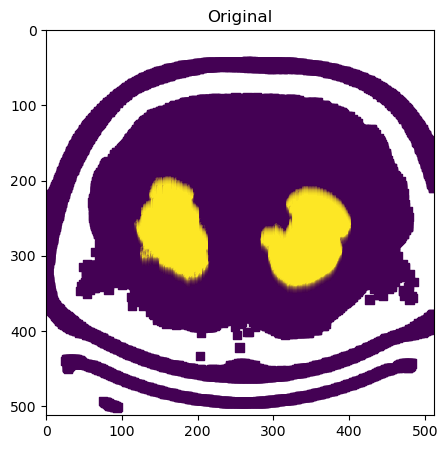

data_0_200/event_kits21_00185.npz


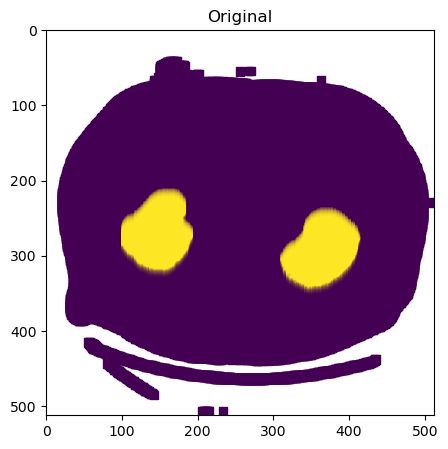

data_0_200/event_kits21_00186.npz


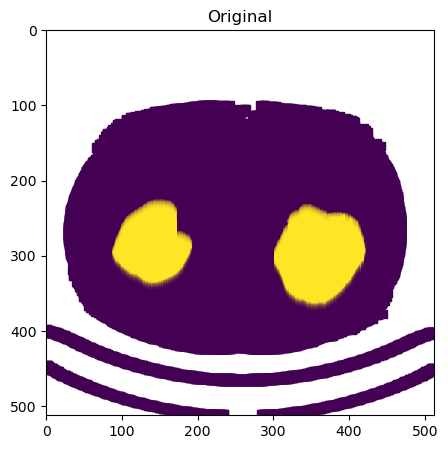

data_0_200/event_kits21_00187.npz


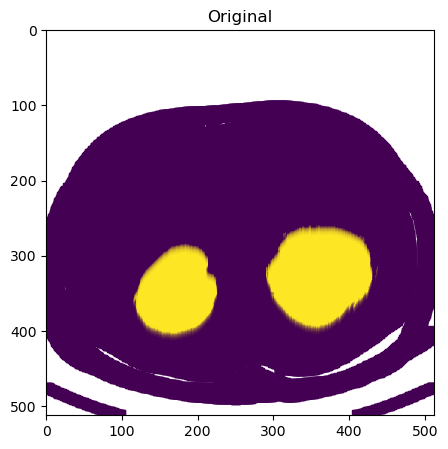

data_0_200/event_kits21_00188.npz


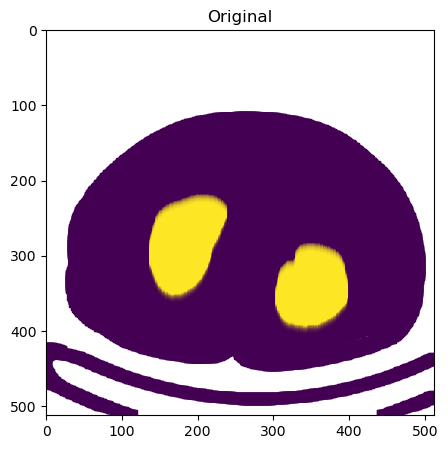

data_0_200/event_kits21_00189.npz


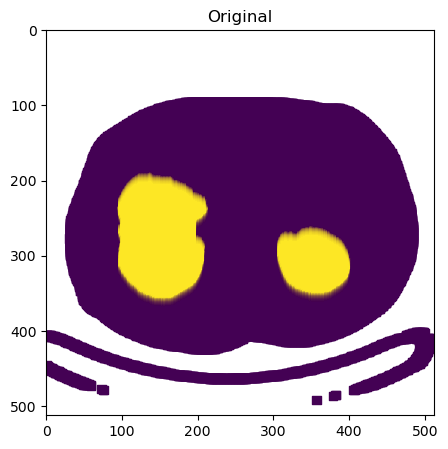

data_0_200/event_kits21_00190.npz


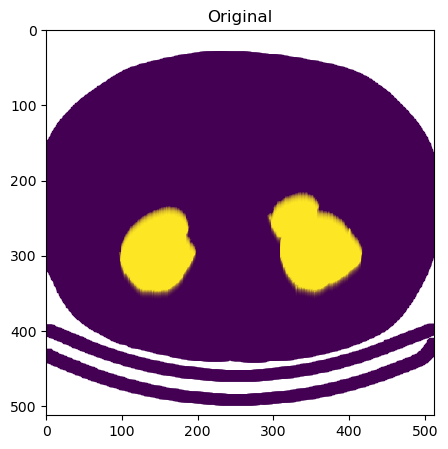

data_0_200/event_kits21_00191.npz


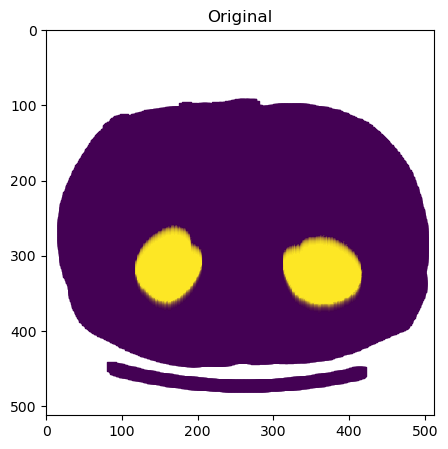

data_0_200/event_kits21_00192.npz


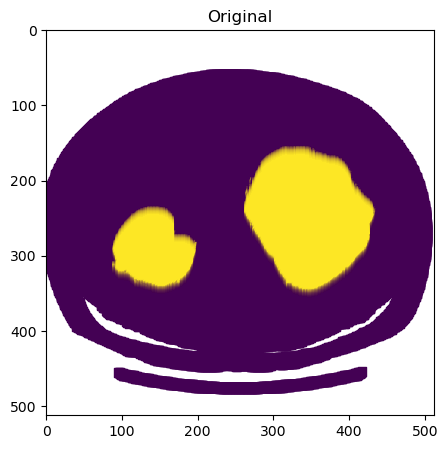

data_0_200/event_kits21_00193.npz


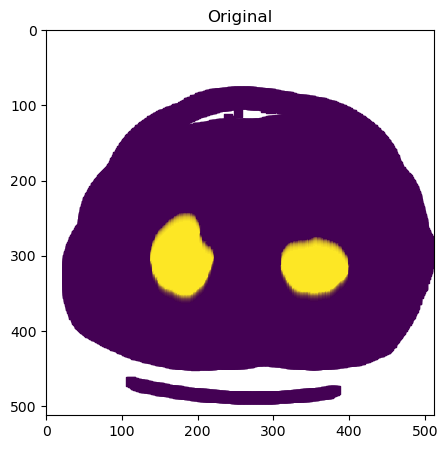

data_0_200/event_kits21_00194.npz


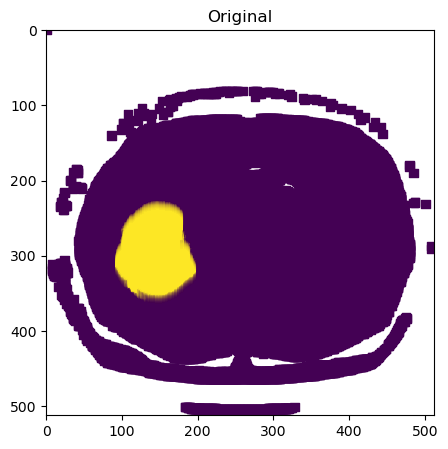

data_0_200/event_kits21_00195.npz


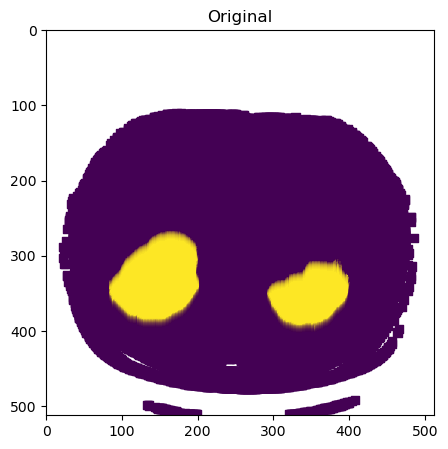

data_0_200/event_kits21_00196.npz


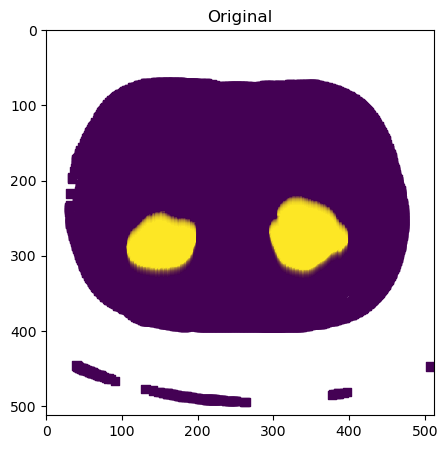

data_0_200/event_kits21_00197.npz


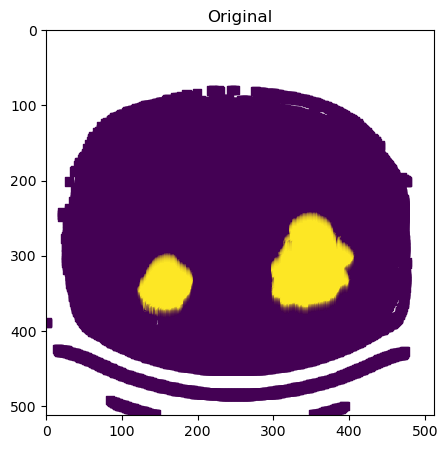

data_0_200/event_kits21_00198.npz


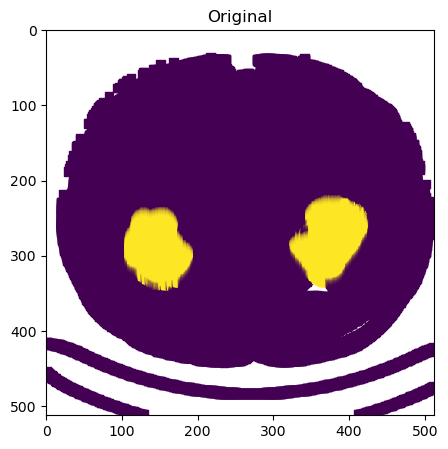

data_0_200/event_kits21_00199.npz


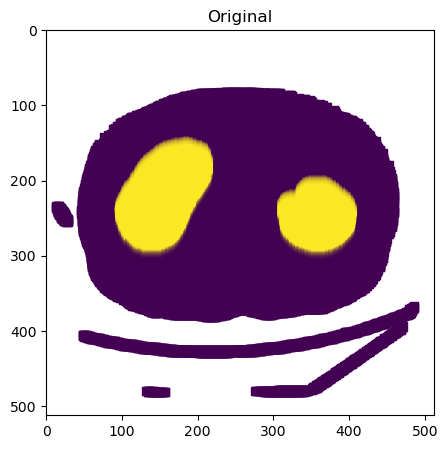

data_0_200/event_kits21_00200.npz


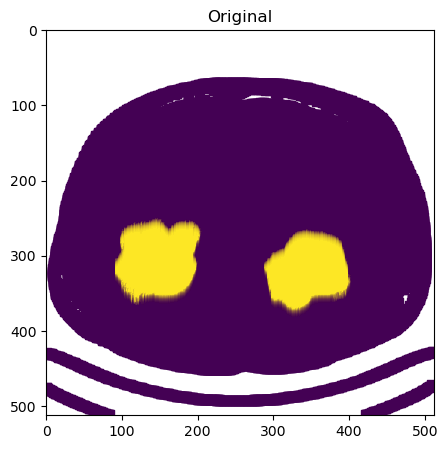

data_0_200/event_kits21_00201.npz


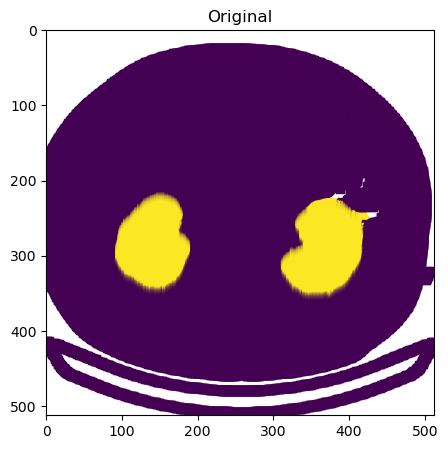

data_0_200/event_kits21_00202.npz


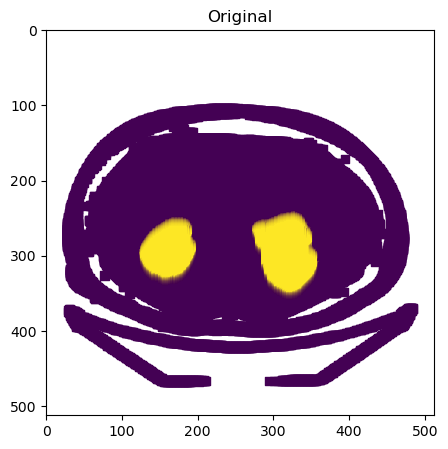

data_0_200/event_kits21_00203.npz


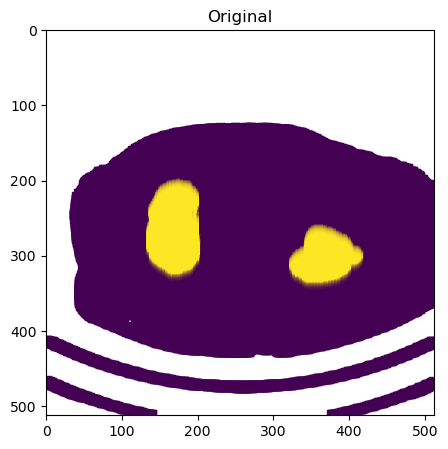

data_0_200/event_kits21_00204.npz


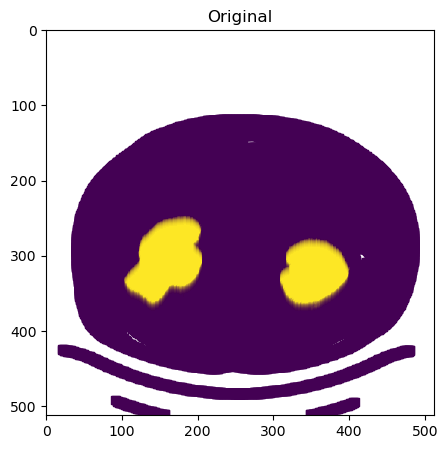

data_0_200/event_kits21_00205.npz


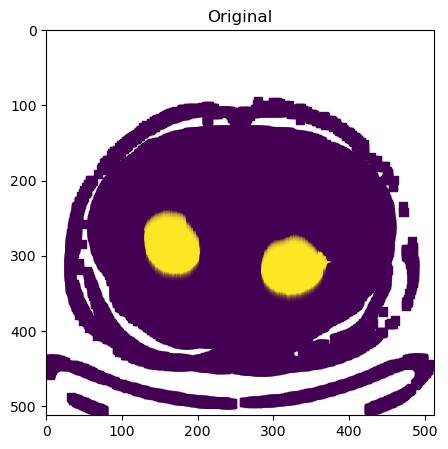

data_0_200/event_kits21_00206.npz


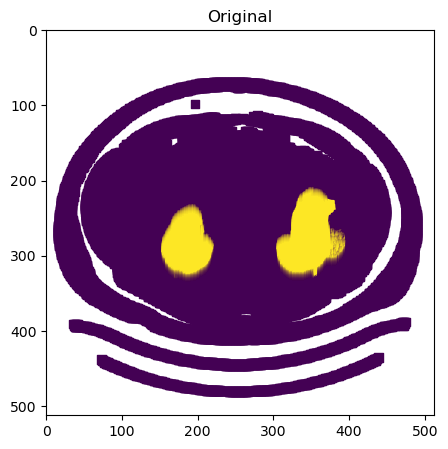

data_0_200/event_kits21_00207.npz


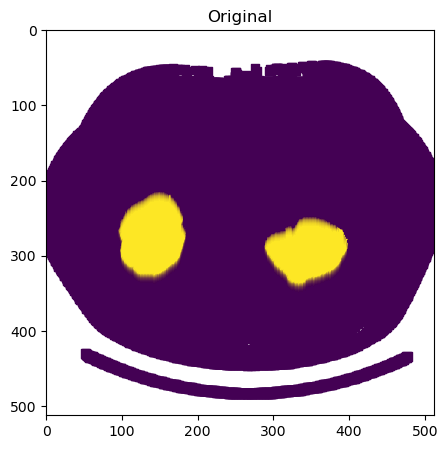

data_0_200/event_kits21_00208.npz


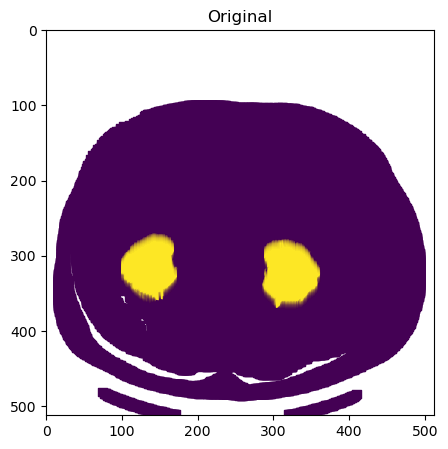

data_0_200/event_kits21_00209.npz


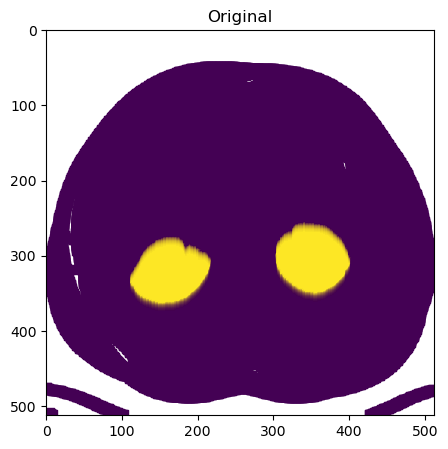

data_0_200/event_kits21_00210.npz


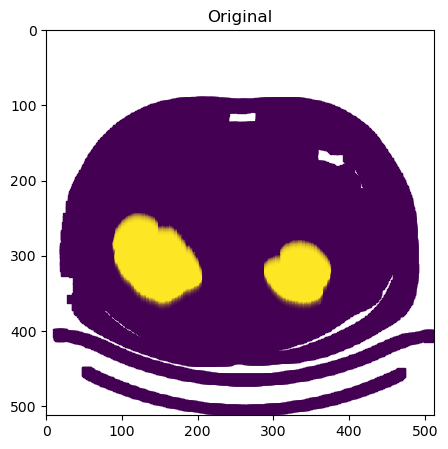

data_0_200/event_kits21_00211.npz


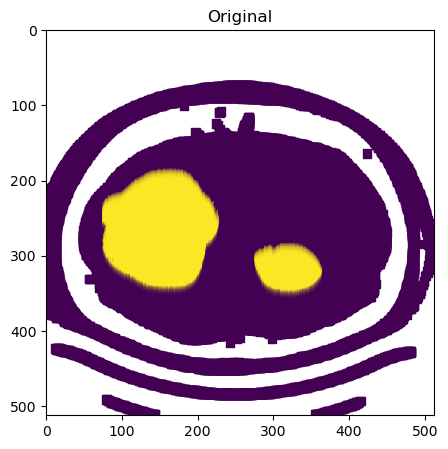

data_0_200/event_kits21_00212.npz


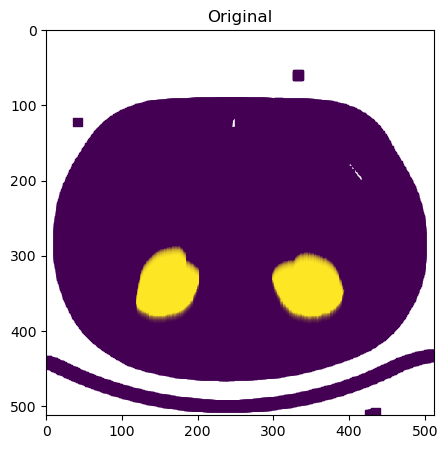

data_0_200/event_kits21_00213.npz


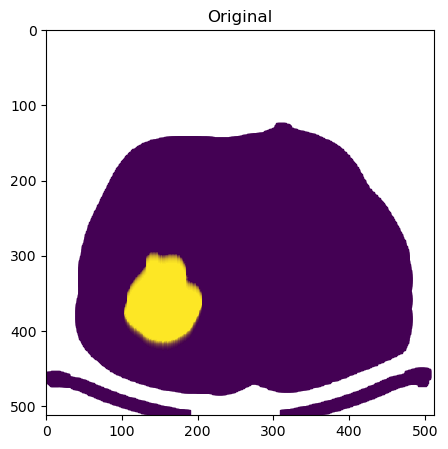

data_0_200/event_kits21_00214.npz


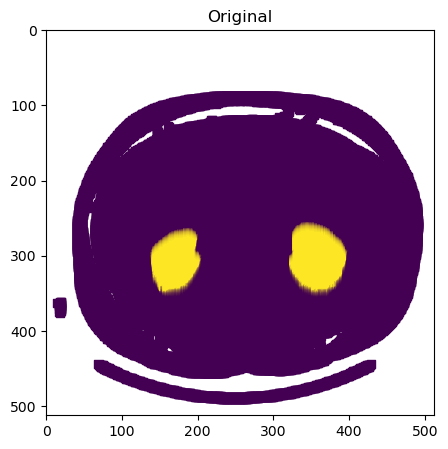

data_0_200/event_kits21_00215.npz


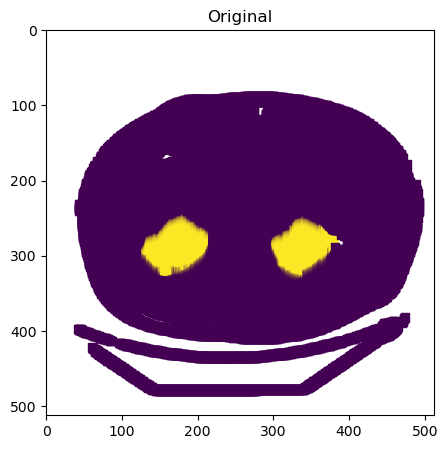

data_0_200/event_kits21_00216.npz


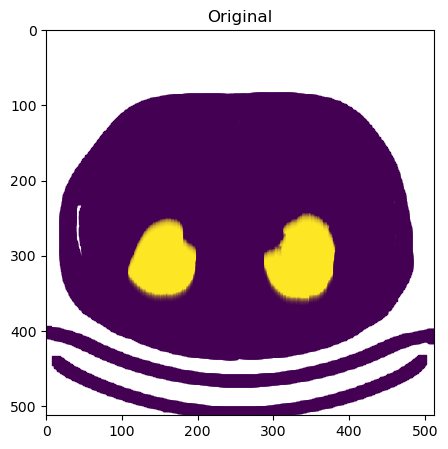

data_0_200/event_kits21_00217.npz


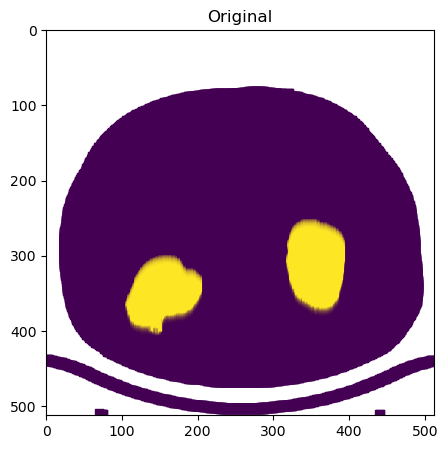

data_0_200/event_kits21_00218.npz


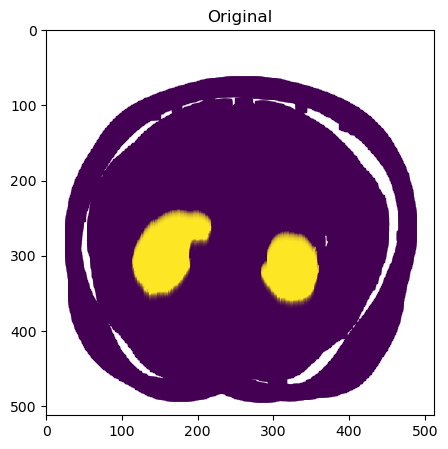

data_0_200/event_kits21_00219.npz


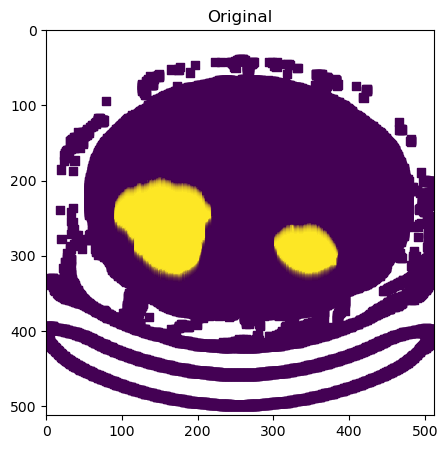

data_0_200/event_kits21_00220.npz


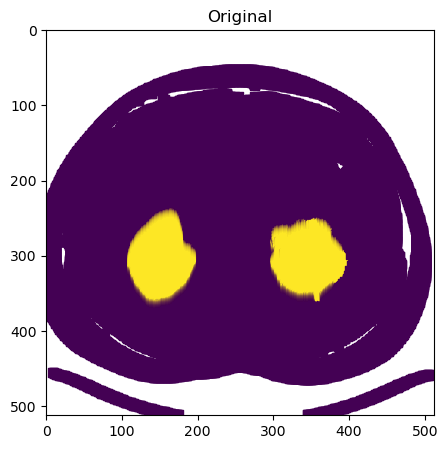

data_0_200/event_kits21_00221.npz


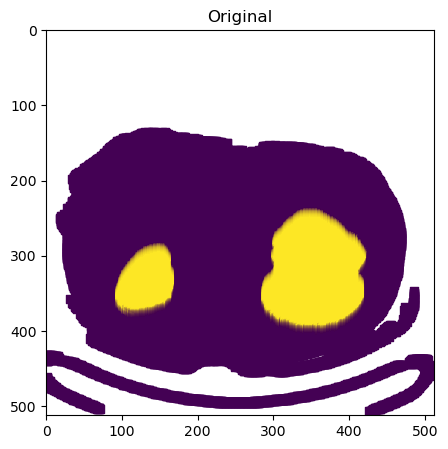

data_0_200/event_kits21_00222.npz


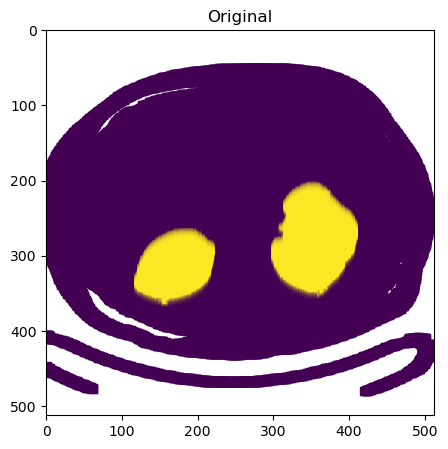

data_0_200/event_kits21_00223.npz


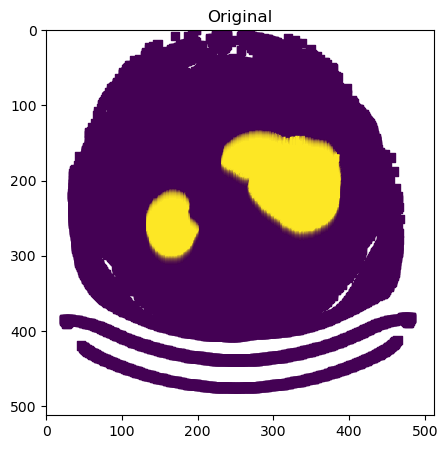

data_0_200/event_kits21_00224.npz


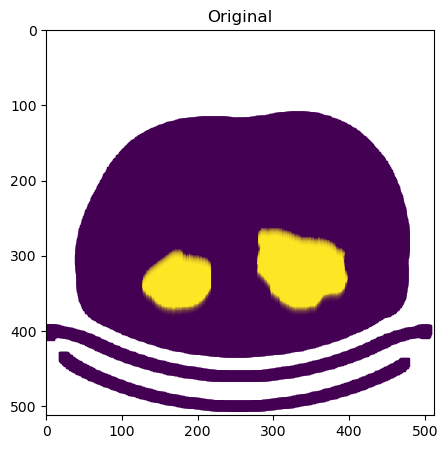

data_0_200/event_kits21_00225.npz


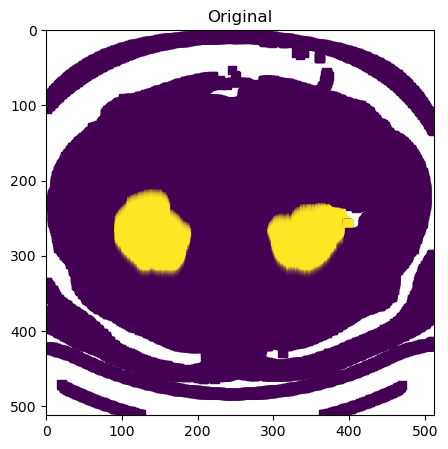

data_0_200/event_kits21_00226.npz


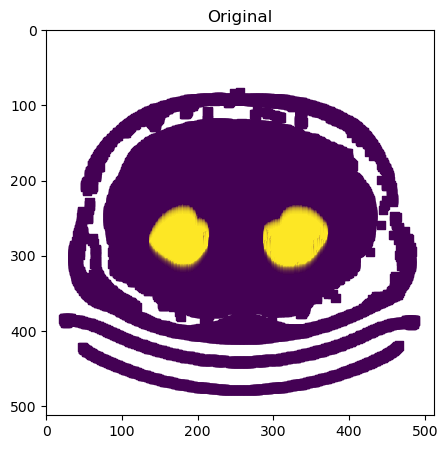

data_0_200/event_kits21_00227.npz


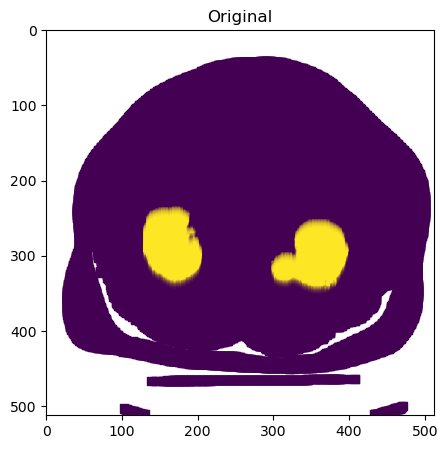

data_0_200/event_kits21_00228.npz


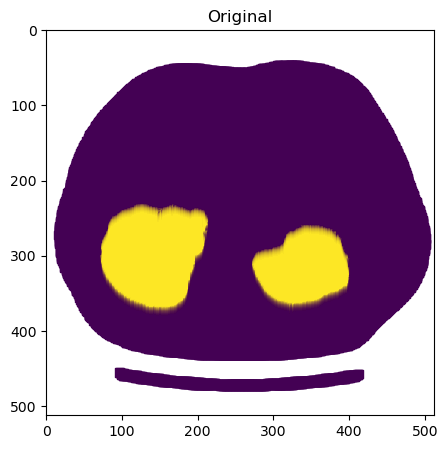

data_0_200/event_kits21_00229.npz


In [ ]:
# plot
for i in range(len(dataset)):
    dataset.combine_slices(i)